# NIPS Curve Processing
Reusable processing and interpretation functions for a single zero curve and one or more sample curves.

**V1 - Took out less noise from the second derivative graph, enabling it to find the *actual* minimum of the curve.**

***What was fixed***: A lot of the proper minimums found were really accurate and ended up fixing the yellow/green regions as well

***Areas to improve***: Sometimes it chooses a less 'certain' minimum rather than the clear one. Needs a more comprehensive system to address it.

**V1-5 - Making the breakpoints better reflect the curve in a *single run.***

sometimes it chooses the wrong minimum. so I would like to have it recognize when its not good (maybe alongside the good fit heuristic though that would require multiple runs) and search 0.3 to the left and 0.3 to the right towards the endpoints of the search, 0 and 0.3 (just so that it doesnt choose the data pt like in that general hump and get the NEXT minimum

if there was a way to compare with one another...

I think I would like to make a separate function where it takes in breakpoint 1 (so i can manually adjust it for testing), generates the segmentation, checks for fit (the heuristic for this needs to be determined, maybe like total errors squared) and doesn't just return True or False, but like a *score*. And the highest score is the one that wins.

Again I would need to make sure that breakpoint 1 is THE ONLY thing wrong with this implementation before doing an automated undertaking, but yea I might have that
It's just that I really just think it would be helpful and more likely to be optimized, but the restructuring of everything might be too much of a task to reliably finish as ameans to just understand the code.

I think my changes for V1-5 is going to focus on curve-unrelated ones for now bc it's really hard to implement it. This just means that the heuristic of 'the yellow line should be below the curve' just cant happen. So I can't use that to systematically check for the next point... *yet*.

**V2 - Attempting to restructure**

I'm going to try to move everything into separate functions because i just really gotta organize things. Having everything lumped into the same thing might not be wise either.

**SECTION 1**: Imports and initialization

In [1]:
import warnings
from pathlib import Path
import datetime

import matplotlib.pyplot as plt
import numpy as np
import copy
import pandas as pd
import piecewise_regression
from pygam import LinearGAM, s
from scipy.signal import find_peaks, peak_prominences ##NEW -- for second deriv analysis
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

def namestr(obj, namespace):          #read the file name of data
    return [name for name in namespace if namespace[name] is obj][0]

LOAD_COL = "Ch:Load (N)"
LVDT_COL = "S:LVDT (in)"
SETPOINT_COL = "Set Point ()"

# ── Save config ──────────────────────────────────────────────────────────
SAVE_PLOTS = True   # set False to disable saving
SAVE_ROOT  = Path(f"pipeline_plots_{datetime.date.today().strftime('%Y-%m-%d')}")
# ─────────────────────────────────────────────────────────────────────────


**SECTION 2**: Data Pre-Processing

In [2]:
def load_curve_data(file_path):
    return pd.read_csv(file_path)

def apply_load_cutoff(df, load_cutoff=1.0, load_col=LOAD_COL):
    return df[df[load_col] >= load_cutoff].copy()

def truncate_sample_keep_creep(
    df,
    lvdt_col=LVDT_COL,
    setpoint_col=SETPOINT_COL,
    creep_threshold=1.0,
    new_col="S:LVDT_shifted (um)",
):
    df = df.sort_index().copy()
    anchor_idx = df.index[-1]
    if setpoint_col in df.columns:
        mask_creep = df[setpoint_col] >= creep_threshold
        if mask_creep.any():
            anchor_idx = df[mask_creep].index[-1]
            df = df.loc[:anchor_idx].copy()
    df[new_col] = (df[lvdt_col]) * 25400.0


    # Remove data after the first point where 'Set Point ()' > 1
    # first_exceed_index = df[df[setpoint_col] > 1].index.min()
    # if not np.isnan(first_exceed_index):  # Check if such a point exists
    #     df = df.loc[:first_exceed_index - 1]  # Truncate data

    return df


def process_curve_raw(file_path, load_cutoff=1.0):
    df = load_curve_data(file_path)
    df_proc = truncate_sample_keep_creep(df)
    df_proc = apply_load_cutoff(df_proc, load_cutoff=load_cutoff)
    return df_proc


def shift_sample_and_zero_curve(
    df_zero,
    df_sample,
    lvdt_col="S:LVDT_shifted (um)",
):  
    df_zero_shift_value = df_zero[lvdt_col].iloc[-1]
    df_zero[lvdt_col] = df_zero[lvdt_col] - df_zero_shift_value
    df_sample[lvdt_col] = df_sample[lvdt_col] - df_zero_shift_value
    return df_zero, df_sample


def subtract_zero_from_sample(
    df_zero,
    df_sample,
    load_col=LOAD_COL,
    zero_disp_col="S:LVDT_shifted (um)",
    sample_disp_col="S:LVDT_shifted (um)",
    new_col="Disp_corrected (um)",
    keep_full_sample_load_range=True,
):
    z = df_zero.sort_values(load_col)
    s = df_sample.sort_values(load_col).copy()
    if not keep_full_sample_load_range:
        min_load = max(z[load_col].min(), s[load_col].min())
        max_load = min(z[load_col].max(), s[load_col].max())
        mask = (s[load_col] >= min_load) & (s[load_col] <= max_load)
        s = s[mask].copy()
    zero_loads = z[load_col].values
    zero_disp = z[zero_disp_col].values
    sample_loads = s[load_col].values
    zero_disp_interp = np.interp(sample_loads, zero_loads, zero_disp)
    s["Zero_interp (um)"] = zero_disp_interp
    s[new_col] = s[sample_disp_col] - zero_disp_interp
    return s



# Evaluation Functions

In [ ]:
def validData_eval(thickness):
    return thickness > 50

def goodData_eval(data, predictions):
    d1 = np.gradient(predictions, data['strain'].values)
    mask = data['strain'].values <= 0.3
    if not mask.any():
        print("goodData_eval: no data below strain 0.2")
        return None
    d1_region = d1[mask]
    strains_region = data['strain'].values[mask]
    window = max(5, len(d1_region) // 15)
    d1_smooth = pd.Series(d1_region).rolling(window, center=True, min_periods=1).mean().values
    prominence_thresh = (d1_smooth.max() - d1_smooth.min()) * 0.05
    maxima, max_props = find_peaks(d1_smooth, prominence=prominence_thresh)
    minima, min_props = find_peaks(-d1_smooth, prominence=prominence_thresh)
    if len(maxima) == 0 and len(minima) == 0:
        print("goodData_eval: no toe region detected (d1 monotone in 0-0.3)")
        return float(strains_region[0])
    candidates = []
    for idx, prom in zip(maxima, max_props['prominences']):
        candidates.append((idx, prom))
    for idx, prom in zip(minima, min_props['prominences']):
        candidates.append((idx, prom))
    best_idx = max(candidates, key=lambda x: x[1])[0]
    toe_end_strain = float(strains_region[best_idx])
    if toe_end_strain >= 0.29:
        print(f"goodData_eval: WARNING — toe extends to {toe_end_strain:.4f}, data may be invalid")
    else:
        print(f"Toe end strain (zero point): {toe_end_strain:.4f}")
    return toe_end_strain

from sklearn.metrics import r2_score

COMPONENTS = [
    ("elastic_r2",               30, "elastic R²"),
    ("plateau_r2_start",         15, "plateau R² (first 40%)"),
    ("densification_r2",         15, "densif R²"),
    ("yield_accuracy",           25, "yield accuracy"),
    ("junction_continuity",      15, "junction continuity"),
    ("plateau_r2_full_penalty",   0, "plateau full R² pen"),
    ("elastic_modulus_penalty",   0, "E-mod penalty"),
    ("bp1_accuracy_penalty",      0, "bp1 penalty"),
]
PENALTY_KEYS = {"plateau_r2_full_penalty", "elastic_modulus_penalty", "bp1_accuracy_penalty"}
CAT_KEYS     = {"catastrophic_slope_vs_modulus", "catastrophic_slope_ordering"}

def goodFit_eval(
    data, elasticRegion, xPlateau, xDensification,
    predElastic, predPlateau, predDensification,
    modelElastic, modelPlateau,
    gam,
    breakpoint1,
    changepoint,
    yieldStrength,
    elasticModulus,
    slopePlateau,
    slopeDensification,
    creep_level=None,
    pass_threshold=70,
):
    score = 0
    breakdown = {}
    data_flags = {}
    catastrophic = False

    w = 30
    if len(elasticRegion) > 1 and predElastic is not None:
        stress = elasticRegion['stress (bar)'].values
        stress_range = stress.max() - stress.min()
        rmse = np.sqrt(np.mean((stress - predElastic) ** 2))
        nrmse_score = max(0.0, 1.0 - rmse / (stress_range + 1e-9))
        pts = round(w * nrmse_score)
        breakdown['elastic_r2'] = (pts, w, f'NRMSE-score={nrmse_score:.3f} (RMSE={rmse:.2f}, range={stress_range:.2f})')
        score += pts
    else:
        breakdown['elastic_r2'] = (0, w, 'insufficient data')

    w = 15
    if xPlateau is not None and len(xPlateau) > 1 and predPlateau is not None:
        cutoff = int(len(xPlateau) * 0.40)
        if cutoff >= 2:
            r2_p = r2_score(xPlateau['stress (bar)'].iloc[:cutoff], predPlateau[:cutoff])
        else:
            r2_p = r2_score(xPlateau['stress (bar)'], predPlateau)
        if r2_p < 0:
            score -= 15
            breakdown['plateau_r2_start'] = (0, w, f'R²(first 40%)={r2_p:.3f} — negative, -15 penalty')
        else:
            pts = round(w * max(r2_p, 0))
            breakdown['plateau_r2_start'] = (pts, w, f'R²(first 40%)={r2_p:.3f}')
            score += pts
    else:
        breakdown['plateau_r2_start'] = (0, w, 'insufficient data')

    w = 15
    if xDensification is not None and len(xDensification) > 1 and predDensification is not None:
        r2_d = r2_score(xDensification['stress (bar)'], predDensification)
        pts = round(w * max(r2_d, 0))
        breakdown['densification_r2'] = (pts, w, f'R²={r2_d:.3f}')
        score += pts
    else:
        breakdown['densification_r2'] = (0, w, 'insufficient data')

    w = 25
    gam_stress_at_bp1 = float(gam.predict([[breakpoint1]])[0])
    yield_err_pct = abs(float(yieldStrength) - gam_stress_at_bp1) / (gam_stress_at_bp1 + 1e-9)
    pts = round(w * max(0, 1 - yield_err_pct / 0.20))
    breakdown['yield_accuracy'] = (pts, w, f'linear vs GAM err={yield_err_pct*100:.1f}%')
    score += pts

    w = 15
    if modelPlateau is not None:
        plateau_at_bp1 = float(modelPlateau.predict([[breakpoint1]])[0])
        junction_err_pct = abs(plateau_at_bp1 - float(yieldStrength)) / (abs(float(yieldStrength)) + 1e-9)
        pts = round(w * max(0, 1 - junction_err_pct / 0.15))
        breakdown['junction_continuity'] = (pts, w, f'gap={junction_err_pct*100:.1f}%')
        score += pts
    else:
        breakdown['junction_continuity'] = (0, w, 'no plateau model')

    if xPlateau is not None and len(xPlateau) > 1 and predPlateau is not None:
        r2_full = r2_score(xPlateau['stress (bar)'], predPlateau)
        penalty = -20 if r2_full < 0.5 else (-10 if r2_full < 0.7 else 0)
        breakdown['plateau_r2_full_penalty'] = (penalty, 0, f'R²(full)={r2_full:.3f}')
        score += penalty

    if elasticModulus <= 0 or not (10 < elasticModulus < 5000):
        breakdown['elastic_modulus_penalty'] = (-5, 0, f'E={elasticModulus:.1f} bar out of range')
        score -= 5
    else:
        breakdown['elastic_modulus_penalty'] = (0, 0, f'E={elasticModulus:.1f} bar ok')

    if xPlateau is not None and len(xPlateau) > 1:
        plateau_strain_range = xPlateau['strain'].max() - xPlateau['strain'].min()
        plateau_stress_rise = slopePlateau * plateau_strain_range
        remaining_stress = data['stress (bar)'].max() - float(yieldStrength)
        rise_fraction = plateau_stress_rise / (remaining_stress + 1e-9)
        if rise_fraction > 0.5:
            breakdown['bp1_accuracy_penalty'] = (-30, 0, f'plateau spans {rise_fraction*100:.0f}% of remaining stress — elastic peak likely wrong')
            score -= 30
        elif rise_fraction > 0.3:
            breakdown['bp1_accuracy_penalty'] = (-15, 0, f'plateau spans {rise_fraction*100:.0f}% of remaining stress — bp1 suspect')
            score -= 15
        else:
            breakdown['bp1_accuracy_penalty'] = (0, 0, f'plateau spans {rise_fraction*100:.0f}% of remaining stress — ok')

    if slopePlateau > elasticModulus:
        catastrophic = True
        breakdown['catastrophic_slope_vs_modulus'] = (0, 0, f'slope={slopePlateau:.1f} > E={elasticModulus:.1f}')
    if slopeDensification <= slopePlateau:
        catastrophic = True
        breakdown['catastrophic_slope_ordering'] = (0, 0, f'densif={slopeDensification:.1f} <= plateau={slopePlateau:.1f}')

    pre_catastrophic_score = score
    if catastrophic:
        score = round(score * 0.5)

    breakdown['_score_final'] = (score, 100, 'after catastrophic halving' if catastrophic else 'no catastrophic applied')

    good = score >= pass_threshold
    for k, (pts, max_pts, note) in breakdown.items():
        if k.startswith('_'):
            continue
        print(f"  {k:35s} {pts:2d}/{max_pts}  {note}")
    if catastrophic:
        print(f"  CATASTROPHIC HALVING: {pre_catastrophic_score} → {score}")
    print(f"Score: {score}/100 → {'PASS' if good else 'FAIL'}")
    return good, breakdown


# Elastic Functions

In [ ]:
def pure_pw(data):
    d1_peak = data["1st derivative"].max()
    low_thresh = d1_peak * 0.15
    in_plateau = data["1st derivative"] < low_thresh
    plateau_start_approx = data["strain"][in_plateau].iloc[0] if in_plateau.any() else 0.1
    plateau_end_approx   = data["strain"][in_plateau].iloc[-1] if in_plateau.any() else 0.5
    cutoff = (plateau_start_approx + plateau_end_approx) / 2
    print(f"Cutoff = {cutoff}")
    region = data[data["strain"] <= cutoff]
    try:
        pw_fit = piecewise_regression.Fit(list(region['strain']), list(region['stress (bar)']), n_breakpoints=1)
    except Exception as e:
        print(f"pure_pw regression failed: {e}")
        return None
    pw_results = pw_fit.get_results()
    if pw_results['estimates']:
        return pw_results['estimates']['breakpoint1']['estimate']
    return None

def double_pw(data, bp1_init, interval):
    tightened = data[(data['strain'] >= bp1_init - interval) & (data['strain'] <= bp1_init + interval)]
    try:
        pw_fit = piecewise_regression.Fit(list(tightened['strain']), list(tightened['stress (bar)']), n_breakpoints=1)
    except Exception as e:
        print(f"double_pw regression failed: {e}")
        return None
    pw_results = pw_fit.get_results()
    if pw_results['estimates']:
        return pw_results['estimates']['breakpoint1']['estimate']
    return None

def elastic_peak(data, predictions):
    data['2nd derivative'].idxmin()
    subset = data[data['strain'] <= 0.3]
    clean_mask = (
        np.isfinite(data['strain']) &
        np.isfinite(data['1st derivative'])
    )
    X_clean = data['strain'][clean_mask].values.reshape(-1, 1)
    y_clean = data['1st derivative'][clean_mask].values

    gam_d1 = LinearGAM(s(0, n_splines=25, lam=0.5, penalties='derivative')).fit(X_clean, y_clean)
    data['1st derivative'] = gam_d1.predict(data['strain'].values.reshape(-1, 1))
    data['2nd derivative'] = np.gradient(data['1st derivative'], data['strain'])

    spike = data['2nd derivative'].diff().abs()
    data.loc[data['2nd derivative'].abs() > 25000, '2nd derivative'] = np.nan
    data.loc[spike > 150, '2nd derivative'] = np.nan
    data['2nd derivative'] = data['2nd derivative'].interpolate(method='linear')

    subset = data[(data['strain'] <= 0.3) & (data['strain'] > 0)]
    if subset.empty or subset['2nd derivative'].isna().all():
        bp1_pw = pure_pw(data)
        return bp1_pw if bp1_pw is not None else float(data['strain'].quantile(0.25))
    if subset['strain'][subset['2nd derivative'].idxmin()] <= 0.02:
        subset = data[(data['strain'] > 0.03) & (data['strain'] <= 0.3)].copy()
    if subset.empty or subset['2nd derivative'].isna().all():
        bp1_pw = pure_pw(data)
        return bp1_pw if bp1_pw is not None else float(data['strain'].quantile(0.25))

    idx_bottom = subset['2nd derivative'].idxmin()
    strain_bottom = subset.loc[idx_bottom, 'strain']
    val_bottom = subset.loc[idx_bottom, '2nd derivative']

    left_side = subset.loc[:idx_bottom]
    val_start = left_side['2nd derivative'].max()
    idx_start = left_side['2nd derivative'].idxmax()

    right_side = subset.loc[idx_bottom:]
    local_window = right_side[right_side['strain'] <= (strain_bottom + 0.05)]
    if not local_window.empty:
        val_end_peak = local_window['2nd derivative'].max()
    else:
        val_end_peak = right_side['2nd derivative'].max()

    total_climb_height = val_end_peak - val_bottom
    flattening_target_y = val_bottom + (total_climb_height * 0.90)
    recovery_zone = right_side[right_side['2nd derivative'] >= flattening_target_y]
    idx_end = recovery_zone.index[0] if not recovery_zone.empty else right_side.index[-1]

    strain_start = subset.loc[idx_start, 'strain']
    strain_end = subset.loc[idx_end, 'strain']
    val_start = subset.loc[idx_start, '2nd derivative']
    val_end = subset.loc[idx_end, '2nd derivative']
    net_height_drop = val_start - val_end

    if net_height_drop > 1500 or val_start - val_bottom > 5000:
        breakpoint1 = (strain_bottom + ((strain_end - strain_bottom) / 2.5))
    else:
        breakpoint1 = strain_bottom

    bp1_pw = pure_pw(data)
    bp1_double = double_pw(data, bp1_pw, 0.1) if bp1_pw is not None else None
    print(f"PW + Double: {bp1_double}")
    if bp1_pw is not None and bp1_pw >= 0 and abs(bp1_pw - breakpoint1) < 0.1:
        print(f"Piecewise Chosen! {bp1_pw} | Drop Calculation: {breakpoint1}")
        return bp1_double if bp1_double is not None and bp1_double <= 0 else bp1_pw
    if bp1_pw is not None and bp1_pw < 0.2:
        print(f"Piecewise Chosen! {bp1_pw} | Drop Calculation: {breakpoint1}")
        return bp1_double if bp1_double is not None and bp1_double <= 0 else bp1_pw
    print(f"Drop Chosen! {breakpoint1} | Piecewise Calculation: {bp1_pw}")
    if double_pw(data, breakpoint1, 0.07):
        return double_pw(data, breakpoint1, 0.07)
    return breakpoint1

def graph_derivs(data, breakpoint1, bp1):
    fig, (fir, sec) = plt.subplots(1, 2, figsize=(10, 4))
    fir.plot(data['strain'], data['1st derivative'], color='green')
    fir.axvline(x=breakpoint1, color='purple', linestyle=':', label='breakpoint1')
    sec.scatter(data['strain'], data['2nd derivative'], color='pink', s=1)
    sec.axvline(x=breakpoint1, color='green', linestyle=':', label='breakpoint1')
    if bp1 is not None:
        sec.axvline(x=bp1, color='blue', linestyle=':', label='PW breakpoint')
    plt.show()


# Plateau/Densification Functions

In [5]:
'''PLATEAU/DENSIFICATION - Returns changepoint, modelPlateau, modelDens'''

def find_changepoint_old(data, regions):
    try:
        pw_fit = piecewise_regression.Fit(list(regions['strain']), list(regions['stress (bar)']), n_breakpoints=4)
    except Exception as e:
        print(f"Piecewise regression fitting failed: {e}")
        return None, None
    
    pw_results = pw_fit.get_results()
    
    if pw_results['estimates'] != None:
        breakpoint2 = pw_results['estimates']['breakpoint1']['estimate']
        breakpoint3 = pw_results['estimates']['breakpoint4']['estimate']
        return breakpoint2, breakpoint3
    
    else:
        return None, None
def find_breakpoints(data, regions):
    for n_bp in [4, 2]:
        try:
            pw_fit = piecewise_regression.Fit(list(regions['strain']), list(regions['stress (bar)']), n_breakpoints=n_bp)
        except Exception as e:
            print(f"pw regression failed (n_bp={n_bp}): {e}")
            continue

        pw_results = pw_fit.get_results()
        if pw_results['estimates'] is None:
            continue  # try fewer breakpoints

        if n_bp == 4:
            breakpoint2      = pw_results['estimates']['breakpoint1']['estimate']
            breakpoint3      = pw_results['estimates']['breakpoint4']['estimate']
            breakpoint_extra2 = pw_results['estimates']['breakpoint2']['estimate']
            breakpoint_extra3 = pw_results['estimates']['breakpoint3']['estimate']

            bp2 = (breakpoint_extra2 - 0.05) if breakpoint2 - regions['strain'].iloc[0] < 0.1 else breakpoint2 + 0.01
            bp3 = (breakpoint_extra3 + 0.01) if regions['strain'].iloc[-1] - breakpoint3 < 0.05 else breakpoint3 - 0.03
        else:
            bp2 = pw_results['estimates']['breakpoint1']['estimate']
            bp3 = pw_results['estimates']['breakpoint2']['estimate']

        return bp2, bp3

    return None, None




def create_changepoint():
    pass

#ok side - we have stress to strain but not the other way around which is VERY annoying
def stress_GAM(gam, strain):
        idx = np.array([[strain]])
        return gam.predict(idx)


# Model Functions

In [6]:
### RELIES ON THE BP2/BP3 METHOD -- MAY BE SCRAPPED AS NEW METHODS ARE DEVISED
def find_changepoint_fit(data, bp1, bp2, bp3, creep_level):
    plateauRegion = data[(bp1 + 0.03 <= data['strain']) & (data['strain'] <= bp2)]
    densificationRegion = data[bp3 <= data['strain']]

    if len(plateauRegion) < 2:
        raise ValueError(f"plateauRegion empty (bp1={bp1:.4f}, bp2={bp2:.4f})")
    if len(densificationRegion) < 2:
        raise ValueError(f"densificationRegion empty (bp3={bp3:.4f})")

    #calculate the plateau region slope
    modelPlateau = LinearRegression()
    modelPlateau.fit(plateauRegion['strain'].values.reshape(-1, 1), plateauRegion['stress (bar)'].values)
    slopePlateau = modelPlateau.coef_[0]
    interceptPlateau = modelPlateau.intercept_

    #calculate the densification region slope
    modelDensification = LinearRegression()
    modelDensification.fit(densificationRegion['strain'].values.reshape(-1, 1), densificationRegion['stress (bar)'].values)
    slopeDensification = modelDensification.coef_[0]
    interceptDensification = modelDensification.intercept_

    #calculate the changepoint between the plateau and densification region
    denom = slopePlateau - slopeDensification
    if abs(denom) < 1e-9:
        changepoint = (bp2 + bp3) / 2  # fallback: midpoint
    else:
        changepoint = (interceptDensification - interceptPlateau) / denom
    xPlateau = data[(bp1 <= data['strain']) & (data['strain'] <= changepoint)]
    xDensification = data[changepoint <= data['strain']]

    predPlateau = modelPlateau.predict(xPlateau[['strain']]) if len(xPlateau) > 0 else np.array([])
    predDensification = modelDensification.predict(xDensification[['strain']]) if len(xDensification) > 0 else np.array([])
    if creep_level is not None and len(predDensification) > 0:
        predDensification[predDensification > creep_level] = creep_level
    return xPlateau, xDensification, predPlateau, predDensification, changepoint, slopePlateau, slopeDensification, modelPlateau
    
##unused
def create_fit_week3(data, bp1, changepoint, creep_level, bp2=None, bp3=None):
    pass


In [7]:
def graph_derivs(data, breakpoint1,bp1):
        fig, (fir, sec) = plt.subplots(1,2, figsize=(10,4))
        #fir.plot(data['strain'], data['1st derivative'], color='green')
        fir.plot(data['strain'], data['1st derivative'], color='green')
        #fir.plot(data['strain'], deriv_for_plot, color='green') - FAILED V0
        #fir.axvline(x=data['2nd derivative'][idx_bottom], color='r', linestyle = ':', label = 'old minimum')
        fir.axvline(x=breakpoint1, color='purple', linestyle = ':', label = 'NEW minimum')
        sec.scatter(data['strain'], data['2nd derivative'], color='pink', s=1)
        #sec.plot(data['strain'], deriv_for_plot, color='black') - FAILED V2
        sec.axvline(x=breakpoint1, color='green', linestyle = ':', label = 'NEW minimum')
        if bp1 is not None:
            sec.axvline(x=bp1, color='blue', linestyle=':', label='PW breakpoint')


def plot_average_curve(processed_curves, cutoff_load_displacement=2, condition_name="", save_dir=None):
    """
    Call once per condition (after all reps processed) to show average stress-strain + CV.
    Comment out the call in process_zero_sample_pairs_pipeline to skip.
    """
    stress_data = []
    strain_data = []

    for df in processed_curves:
        d = df[df['Ch:Load (N)'] > cutoff_load_displacement].copy()
        if 'Set Point ()' in d.columns and (d['Set Point ()'] > 1).any():
            d = d[d['Set Point ()'] <= 1].copy()
        if 'stress (bar)' not in d.columns or 'strain' not in d.columns:
            continue
        d = d.sort_values('stress (bar)').reset_index(drop=True)
        d['strain'] = d['strain'] - d['strain'].iloc[0]
        stress_data.append(d['stress (bar)'].values)
        strain_data.append(d['strain'].values)

    if not stress_data:
        return None

    common_min = max(s[0]  for s in stress_data)
    common_max = min(s[-1] for s in stress_data)
    n_pts      = min(len(s) for s in stress_data)
    common_stress = np.linspace(common_min, common_max, n_pts)

    aligned = np.array([
        np.interp(common_stress, stress, strain)
        for stress, strain in zip(stress_data, strain_data)
    ])
    avg_strain = np.mean(aligned, axis=0)
    std_strain = np.std(aligned,  axis=0)

    overall_avg = np.mean(avg_strain)
    overall_std = np.mean(std_strain)
    cv = overall_std / overall_avg if overall_avg != 0 else np.nan

    plt.figure(figsize=(8, 5.5))
    for i, (stress, strain) in enumerate(zip(stress_data, strain_data)):
        plt.plot(strain, stress, alpha=0.35, linewidth=1, label=f"Rep {i+1}")
    plt.plot(avg_strain, common_stress, color='black', linewidth=2.5, label='Average')
    plt.fill_betweenx(common_stress,
                      avg_strain - std_strain,
                      avg_strain + std_strain,
                      color='grey', alpha=0.3, label='+/-1 SD')
    plt.plot([],[], label=f'CV = {cv}')

    plt.xlabel('Strain', fontsize=16)
    plt.ylabel('Stress (bar)', fontsize=16)
    plt.title(condition_name, fontsize=14)
    plt.legend(fontsize=10)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    
    if SAVE_PLOTS and save_dir is not None:
        _sd = Path(save_dir)
        _sd.mkdir(parents=True, exist_ok=True)
        plt.savefig(_sd / "Comparison_CV.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"CV ({condition_name}): {cv:.4f}")
    return cv


# Terminology for Section 4

*elasticRegion* - x and y values of DATA up until breakpoint1 (how is this used to graph?)
*xPlateau/Densification* - ALSO x and y values of data, but based on the changepoint

In [ ]:
def interpretData(data_list, thickness_info=True, thickness_list=None, creep_info=True,
                  cutoff_load_thickness=1, cutoff_load_displacement=2, save_path=None):
    thickness = thickness_list if thickness_info else []
    if not thickness_info:
        for i in range(len(data_list)):
            thickness.append(-data_list[i]["Disp_corrected (um)"][data_list[i]['Ch:Load (N)'] > cutoff_load_thickness].iloc[0])

    mechanicalProperties = []

    for i in range(len(data_list)):
        data_list[i]['stress (bar)'] = data_list[i]['Ch:Load (N)'] / 19.635 * 10
        data_list[i]['strain'] = data_list[i]['Disp_corrected (um)'] / thickness[i]

    all_stress_data = []
    for i in range(len(data_list)):
        data = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement]
        data['strain'] = data['strain'] - data['strain'].iloc[0]
        data = data.reset_index(drop=True)
        all_stress_data.append(data['stress (bar)'].values)
    min_length = min(len(s) for s in all_stress_data)
    avg_standard_deviation = np.mean([np.std(s[:min_length]) for s in all_stress_data])
    print(f"\n\n------------ NEW REP ---------------")
    print(f"Average Standard Deviation: {avg_standard_deviation}")

    for i in range(len(data_list)):
        plt.figure(figsize=(8, 5.5))

        if 'display_name' in data_list[i].columns and len(data_list[i]['display_name']) > 0:
            data_name = str(data_list[i]['display_name'].iloc[0])
        elif 'name' in data_list[i].columns and len(data_list[i]['name']) > 0:
            data_name = str(data_list[i]['name'].iloc[0])
        elif 'source_file' in data_list[i].columns and len(data_list[i]['source_file']) > 0:
            data_name = str(data_list[i]['source_file'].iloc[0]).rsplit('.', 1)[0]
        else:
            data_name = namestr(data_list[i], globals())
        if 'trial_label' in data_list[i].columns and len(data_list[i]['trial_label']) > 0:
            trial = str(data_list[i]['trial_label'].iloc[0])
        elif 'sample_num' in data_list[i].columns and len(data_list[i]['sample_num']) > 0:
            trial = f"sample {int(data_list[i]['sample_num'].iloc[0])}"
        else:
            trial = data_name.split('_')[-1]

        if not validData_eval(thickness[i]):
            print(f"Skipping GAM for {data_name} (thickness={thickness[i]:.1f} µm — no membrane)")
            _raw = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement].copy()
            plt.scatter(_raw['Disp_corrected (um)'], _raw['stress (bar)'], color='lightgrey', s=2)
            plt.title(f"{data_name} — no membrane detected", fontsize=12)
            plt.xlabel("Disp_corrected (um)"); plt.ylabel("stress (bar)")
            if save_path is not None:
                Path(save_path).parent.mkdir(parents=True, exist_ok=True)
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.show()
            mechanicalProperties.append({
                'name': data_name, 'Trial': trial, 'Thickness': thickness[i],
                'Elastic Modulus': np.nan, 'Yield Strength': np.nan, 'Changepoint': np.nan,
                'Slope Plateau': np.nan, 'Slope Densification': np.nan, 'Creep Strain': np.nan,
                'Strain at 50 bar': np.nan, 'Strain at 80 bar': np.nan,
                'Strain at 150 bar': np.nan, 'Strain at 500 bar': np.nan,
                'Good Fit': False, 'Good Fit Score': None, 'Good Fit Breakdown': None,
                'Average Standard Deviation': avg_standard_deviation,
            })
            continue

        data = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement]
        data['strain'] = data['strain'] - data['strain'].iloc[0]
        data = data.reset_index(drop=True)
        fracture_index = data['stress (bar)'].idxmax()
        has_creep_segment = creep_info and (data['Set Point ()'] > 1).any()
        if has_creep_segment:
            fracture_index = data[data['Set Point ()'] > 1].index[0] + 1
        else:
            fracture_index += 1
        data_original = data.copy()
        data = data.iloc[:fracture_index]

        creep_strain = None
        creep_level = None
        if has_creep_segment:
            creep_segment = data_original[data_original['Set Point ()'] > 1]['stress (bar)']
            creep_level = float(creep_segment.mean())
            creep_start = data_original[data_original['Set Point ()'] > 1]['strain'].min()
            creep_end   = data_original[data_original['Set Point ()'] > 1]['strain'].max()
            plt.hlines(creep_level, creep_start, creep_end, color='red', label='Creep Region', linewidth=3, zorder=100)
            creep_strain = creep_end - creep_start

        creep_end_index = data_original[data_original['Set Point ()'] > 1].index[-1] + 1 if has_creep_segment else fracture_index

        try:
            gam = LinearGAM(s(0))
            gam.fit(data[['strain']], data['stress (bar)'])
            predictions = gam.predict(data[['strain']])
        except Exception as e:
            print(f"  GAM fit failed: {e} — skipping")
            plt.close()
            mechanicalProperties.append({
                'name': data_name, 'Trial': trial, 'Thickness': thickness[i],
                'Elastic Modulus': np.nan, 'Yield Strength': np.nan, 'Changepoint': np.nan,
                'Slope Plateau': np.nan, 'Slope Densification': np.nan, 'Creep Strain': creep_strain,
                'Strain at 50 bar': np.nan, 'Strain at 80 bar': np.nan,
                'Strain at 150 bar': np.nan, 'Strain at 500 bar': np.nan,
                'Good Fit': False, 'Good Fit Score': 0, 'Good Fit Breakdown': None,
                'Average Standard Deviation': avg_standard_deviation,
            })
            continue

        goodData_eval(data, predictions)
        predictions_for_plot = predictions.copy()
        predictions_for_plot[predictions_for_plot > creep_level] = creep_level if creep_level is not None else predictions[-1]
        plt.plot(data['strain'], predictions_for_plot, color='black', label='Spline Model')

        if 'Set Point ()' in data_original.columns:
            loading_region = data_original[data_original['Set Point ()'] <= 1].copy()
        else:
            loading_region = data_original.copy()

        def strain_at_stress_from_gam(target_stress):
            if loading_region.empty: return np.nan
            lr = loading_region[['strain']].dropna().copy()
            if lr.empty: return np.nan
            gam_stress = gam.predict(lr[['strain']]).astype(float)
            if target_stress < np.min(gam_stress) or target_stress > np.max(gam_stress): return np.nan
            return float(lr['strain'].iloc[int(np.argmin(np.abs(gam_stress - target_stress)))])

        strain_50bar  = strain_at_stress_from_gam(50)
        strain_80bar  = strain_at_stress_from_gam(80)
        strain_150bar = strain_at_stress_from_gam(150)
        strain_500bar = strain_at_stress_from_gam(500)

        plt.scatter(data_original.iloc[:creep_end_index]['strain'],
                    data_original.iloc[:creep_end_index]['stress (bar)'],
                    color='lightgrey', label='Raw Data')

        data['1st derivative'] = np.gradient(predictions, data['strain'])
        data['2nd derivative'] = np.gradient(data['1st derivative'], data['strain'])

        try:
            breakpoint1 = elastic_peak(data, predictions)
        except Exception as e:
            print(f"  elastic_peak failed: {e} — using quantile fallback")
            breakpoint1 = float(data['strain'].quantile(0.25))

        elasticRegion = data[data['strain'] <= breakpoint1]
        if len(elasticRegion) < 2:
            breakpoint1 = float(data['strain'].quantile(0.25))
            elasticRegion = data[data['strain'] <= breakpoint1]

        elastic_fit_failed = len(elasticRegion) < 2
        if elastic_fit_failed:
            modelElastic = None; elasticModulus = 0.0
            yieldStrength = np.array([0.0]); predElastic = None
        else:
            modelElastic = LinearRegression()
            modelElastic.fit(elasticRegion['strain'].values.reshape(-1, 1), elasticRegion['stress (bar)'].values)
            elasticModulus = modelElastic.coef_[0]
            yieldStrength  = modelElastic.predict(np.array([[breakpoint1]]))
            predElastic    = modelElastic.predict(elasticRegion[['strain']])

        regions = data[data['strain'] >= breakpoint1]
        bp2, bp3 = find_breakpoints(data, regions)
        if bp2 is None:
            print(f"  find_breakpoints returned None — skipping")
            plt.close()
            mechanicalProperties.append({
                'name': data_name, 'Trial': trial, 'Thickness': thickness[i],
                'Elastic Modulus': elasticModulus, 'Yield Strength': float(yieldStrength[0]),
                'Changepoint': np.nan, 'Slope Plateau': np.nan, 'Slope Densification': np.nan,
                'Creep Strain': creep_strain,
                'Strain at 50 bar': strain_50bar, 'Strain at 80 bar': strain_80bar,
                'Strain at 150 bar': strain_150bar, 'Strain at 500 bar': strain_500bar,
                'Good Fit': False, 'Good Fit Score': 0, 'Good Fit Breakdown': None,
                'Average Standard Deviation': avg_standard_deviation,
            })
            continue

        try:
            xPlateau, xDensification, predPlateau, predDensification, changepoint, slopePlateau, slopeDensification, modelPlateau = find_changepoint_fit(data, breakpoint1, bp2, bp3, creep_level)
        except ValueError as e:
            print(f"  find_changepoint_fit failed: {e}")
            plt.close()
            mechanicalProperties.append({
                'name': data_name, 'Trial': trial, 'Thickness': thickness[i],
                'Elastic Modulus': elasticModulus, 'Yield Strength': float(yieldStrength[0]),
                'Changepoint': np.nan, 'Slope Plateau': np.nan, 'Slope Densification': np.nan,
                'Creep Strain': creep_strain,
                'Strain at 50 bar': strain_50bar, 'Strain at 80 bar': strain_80bar,
                'Strain at 150 bar': strain_150bar, 'Strain at 500 bar': strain_500bar,
                'Good Fit': False, 'Good Fit Score': 0, 'Good Fit Breakdown': None,
                'Average Standard Deviation': avg_standard_deviation,
            })
            continue

        if elastic_fit_failed:
            good = False
            fit_breakdown = {'_score_final': (0, 100, 'elastic fit failed')}
        else:
            try:
                good, fit_breakdown = goodFit_eval(
                    data, elasticRegion, xPlateau, xDensification,
                    predElastic, predPlateau, predDensification,
                    modelElastic, modelPlateau, gam,
                    breakpoint1, changepoint, float(yieldStrength[0]),
                    elasticModulus, slopePlateau, slopeDensification,
                    creep_level=creep_level, pass_threshold=70,
                )
            except Exception as e:
                print(f"  goodFit_eval failed: {e}")
                good = False
                fit_breakdown = {'_score_final': (0, 100, str(e))}

        import json as _json
        mechanicalProperties.append({
            'name': data_name, 'Trial': trial, 'Thickness': thickness[i],
            'Elastic Modulus': elasticModulus, 'Yield Strength': yieldStrength[0],
            'Changepoint': changepoint, 'Slope Plateau': slopePlateau,
            'Slope Densification': slopeDensification, 'Creep Strain': creep_strain,
            'Strain at 50 bar': strain_50bar, 'Strain at 80 bar': strain_80bar,
            'Strain at 150 bar': strain_150bar, 'Strain at 500 bar': strain_500bar,
            'Good Fit': good,
            'Good Fit Score': fit_breakdown.get('_score_final', (None,))[0],
            'Good Fit Breakdown': _json.dumps({k: {'pts': v[0], 'max': v[1], 'note': v[2]} for k, v in fit_breakdown.items()}),
            'Average Standard Deviation': avg_standard_deviation,
        })

        if predElastic is not None:
            plt.plot(elasticRegion['strain'], predElastic, color='blue', label='Elastic Region', linewidth=3)
        if predPlateau is not None:
            plt.plot(xPlateau['strain'], predPlateau, color='orange', label='Plateau Region', linewidth=3)
        if predDensification is not None:
            plt.plot(xDensification['strain'], predDensification, color='green', label='Densification Region', linewidth=3)

        _ref_points = [(50, strain_50bar, 'mediumpurple'), (80, strain_80bar, 'darkcyan'),
                       (150, strain_150bar, 'coral'), (500, strain_500bar, 'steelblue')]
        _ax = plt.gca()
        _xlim, _ylim = _ax.get_xlim(), _ax.get_ylim()
        for stress_val, strain_val, color in _ref_points:
            if strain_val is not None and not np.isnan(strain_val):
                plt.plot([_xlim[0], strain_val], [stress_val, stress_val], color=color, linestyle=':', linewidth=1, alpha=0.9)
                plt.plot([strain_val, strain_val], [_ylim[0], stress_val], color=color, linestyle=':', linewidth=1, alpha=0.9,
                         label=f'{stress_val} bar | ε = {strain_val:.3f}')
        _ax.set_xlim(_xlim); _ax.set_ylim(_ylim)

        plt.title(data_name, fontsize=14)
        plt.xlabel('Strain', fontsize=20); plt.ylabel('Stress (bar)', fontsize=20)
        plt.legend(loc='upper left', fontsize=11)
        plt.xticks(fontsize=16); plt.yticks(fontsize=16)
        plt.tight_layout()
        if save_path is not None:
            Path(save_path).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        graph_derivs(data, breakpoint1, pure_pw(data))

    return mechanicalProperties


In [ ]:
import re, json
from datetime import datetime
SPECIMEN_PATTERN = re.compile(r"^Specimen_(\d+)_(\d{8})_(\d{6})\.csv$")

def _parse_specimen_file_info(csv_path):
    name = Path(csv_path).name
    match = SPECIMEN_PATTERN.match(name)
    if not match:
        return None
    specimen_id = int(match.group(1))
    dt_str = "{}{}".format(match.group(2), match.group(3))
    timestamp = datetime.strptime(dt_str, "%m%d%Y%H%M%S")
    return {"path": str(Path(csv_path)), "name": name,
            "specimen_id": specimen_id, "timestamp": timestamp}

def _pair_chronological_zero_sample(specimen_rows, strict=True, cluster_gap_minutes=15):
    rows_sorted = sorted(specimen_rows, key=lambda row: (row["timestamp"], row["specimen_id"]))
    if len(rows_sorted) == 0:
        return []
    clusters = [[rows_sorted[0]]]
    for prev, curr in zip(rows_sorted, rows_sorted[1:]):
        gap_min = (curr["timestamp"] - prev["timestamp"]).total_seconds() / 60
        if gap_min > cluster_gap_minutes:
            clusters.append([curr])
        else:
            clusters[-1].append(curr)
    if len(clusters) == 1:
        mid = len(clusters[0]) // 2
        clusters = [clusters[0][:mid], clusters[0][mid:]]
        print(f"Single cluster — split in half: {len(clusters[0])} zeros, {len(clusters[1])} membranes")
    if strict and len(clusters) % 2 != 0:
        raise ValueError("Expected even number of clusters, got {}.".format(len(clusters)))
    pairs = []
    replicate = 1
    for i in range(0, len(clusters), 2):
        zero_cluster = clusters[i]
        membrane_cluster = clusters[i + 1]
        if strict and len(zero_cluster) != len(membrane_cluster):
            raise ValueError("Zero cluster ({}) and membrane cluster ({}) sizes differ.".format(
                len(zero_cluster), len(membrane_cluster)))
        for zero_row, sample_row in zip(zero_cluster, membrane_cluster):
            pairs.append({
                "replicate": replicate,
                "zero_file": zero_row["path"],
                "sample_file": sample_row["path"],
                "zero_specimen": zero_row["specimen_id"],
                "sample_specimen": sample_row["specimen_id"],
                "zero_time": zero_row["timestamp"],
                "sample_time": sample_row["timestamp"],
            })
            replicate += 1
    return pairs

def load_zero_sample_pairs_by_condition(folder_name, data_root="Data", strict=True,
                                         load_dataframes=False, condition_filter=None):
    base_dir = Path(data_root) / folder_name
    if not base_dir.exists():
        raise FileNotFoundError("Folder not found: {}".format(base_dir))
    result = {}
    for condition_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        if condition_filter and condition_dir.name != condition_filter:
            continue
        csv_files = sorted(condition_dir.glob("*.csv"))
        specimen_rows = []
        for csv_file in csv_files:
            parsed = _parse_specimen_file_info(csv_file)
            if parsed is not None:
                specimen_rows.append(parsed)
        if len(specimen_rows) == 0:
            continue
        cluster_gap = 15
        params_file = condition_dir / "params.json"
        if params_file.exists():
            try:
                with open(params_file) as _pf:
                    _p = json.load(_pf)
                nips_s = _p.get("nips_bath_wait_time", 900)
                cluster_gap = 15 if nips_s < 660 else nips_s / 60 / 2 + 4
            except Exception:
                pass
        pairs = _pair_chronological_zero_sample(specimen_rows, strict=strict, cluster_gap_minutes=cluster_gap)
        if load_dataframes:
            for pair in pairs:
                pair["zero_df"] = pd.read_csv(pair["zero_file"])
                pair["sample_df"] = pd.read_csv(pair["sample_file"])
        result[condition_dir.name] = {
            "condition": condition_dir.name,
            "folder": str(condition_dir),
            "num_files": len(specimen_rows),
            "num_pairs": len(pairs),
            "pairs": pairs,
        }
    return result

def pairs_to_dataframe(pairs_by_condition):
    rows = []
    for condition_name, payload in pairs_by_condition.items():
        for pair in payload["pairs"]:
            rows.append({
                "condition": condition_name,
                "replicate": pair["replicate"],
                "zero_specimen": pair["zero_specimen"],
                "sample_specimen": pair["sample_specimen"],
                "zero_file": pair["zero_file"],
                "sample_file": pair["sample_file"],
                "zero_time": pair["zero_time"],
                "sample_time": pair["sample_time"],
            })
    return pd.DataFrame(rows)


In [10]:
pairs_by_condition = load_zero_sample_pairs_by_condition("compression-test-data", data_root=".", strict=True, load_dataframes=False)
pairs_preview = pairs_to_dataframe(pairs_by_condition)
pairs_preview

,condition,replicate,zero_specimen,sample_specimen,zero_file,sample_file,zero_time,sample_time
0,17-13deg-10s-NoN2-30s,1,7,10,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:50:49,2026-06-02 16:03:14
1,17-13deg-10s-NoN2-30s,2,8,11,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:54:06,2026-06-02 16:07:32
2,17-13deg-10s-NoN2-30s,3,9,12,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:57:15,2026-06-02 16:11:24
3,17-13deg-10s-NoN2-40s,1,13,16,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:17:48,2026-06-01 16:30:49
4,17-13deg-10s-NoN2-40s,2,14,17,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:21:06,2026-06-01 16:34:53
5,17-13deg-10s-NoN2-40s,3,15,18,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:24:25,2026-06-01 16:38:52
6,17-13deg-120s-NoN2-1800s,1,1,4,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:36:33,2026-05-28 17:21:44
7,17-13deg-120s-NoN2-1800s,2,2,5,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:40:16,2026-05-28 17:26:13
8,17-13deg-120s-NoN2-1800s,3,3,6,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:43:53,2026-05-28 17:30:25
9,17-13deg-120s-NoN2-1900s,1,1,4,compression-test-data/17-13deg-120s-NoN2-1900s...,compression-test-data/17-13deg-120s-NoN2-1900s...,2026-05-29 12:41:02,2026-05-29 13:26:32


In [11]:
def process_zero_sample_pairs_pipeline(
    folder_name,
    data_root="Data",
    strict=True,
    load_cutoff=1.0,
    thickness_info=False,
    thickness_map=None,
    creep_info=True,
    cutoff_load_thickness=1,
    cutoff_load_displacement=2,
):
    """
    Run the full curve processing pipeline for all paired zero/sample curves in a folder.

    For each pair, this function:
    1) Processes raw curves via process_curve_raw()
    2) Aligns curves via shift_sample_and_zero_curve()
    3) Produces corrected sample via subtract_zero_from_sample()
    4) Shows a diagnostic figure with raw-processed, shifted, and corrected curves
    5) Shows interpretData() output figure for the corrected sample
    """
    pairs_by_condition = load_zero_sample_pairs_by_condition(
        folder_name=folder_name,
        data_root=data_root,
        strict=strict,
        load_dataframes=False,
    )

    pipeline_result = {}

    for condition_name, payload in pairs_by_condition.items():
        ## MAKE CONDITION NAME FOLDER?
        
        print("=" * 110)
        print("Condition: {} | pairs: {}".format(condition_name, payload["num_pairs"]))

        condition_processed_curves = []
        condition_valid_curves = []
        condition_properties = []

        for pair in payload["pairs"]:

            zero_file = pair["zero_file"]
            sample_file = pair["sample_file"]
            replicate = pair["replicate"]

            zero_raw_processed = process_curve_raw(zero_file, load_cutoff=load_cutoff)
            sample_raw_processed = process_curve_raw(sample_file, load_cutoff=load_cutoff)

            zero_shifted, sample_shifted = shift_sample_and_zero_curve(
                zero_raw_processed.copy(),
                sample_raw_processed.copy(),
            )

            processed_sample_curve = subtract_zero_from_sample(
                zero_shifted.copy(),
                sample_shifted.copy(),
            )

            display_name = "{} | rep {}".format(condition_name, replicate)
            processed_sample_curve["display_name"] = display_name
            processed_sample_curve["trial_label"] = "sample {}".format(pair["sample_specimen"])
            processed_sample_curve["source_file"] = Path(sample_file).name

            condition_processed_curves.append(processed_sample_curve)

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            fig.suptitle(display_name, fontsize=14)

            axes[0].plot(
                zero_raw_processed["S:LVDT_shifted (um)"],
                zero_raw_processed[LOAD_COL],
                label="Zero (after process_curve_raw)",
            )
            axes[0].plot(
                sample_raw_processed["S:LVDT_shifted (um)"],
                sample_raw_processed[LOAD_COL],
                label="Sample (after process_curve_raw)",
            )
            axes[0].set_title("Raw Curves (Processed)")
            axes[0].set_xlabel("S:LVDT_shifted (um)")
            axes[0].set_ylabel("Load (N)")
            axes[0].legend(fontsize=8)

            axes[1].plot(
                zero_shifted["S:LVDT_shifted (um)"],
                zero_shifted[LOAD_COL],
                label="Zero (after shift)",
            )
            axes[1].plot(
                sample_shifted["S:LVDT_shifted (um)"],
                sample_shifted[LOAD_COL],
                label="Sample (after shift)",
            )
            axes[1].set_title("Shifted Curves")
            axes[1].set_xlabel("S:LVDT_shifted (um)")
            axes[1].set_ylabel("Load (N)")
            axes[1].legend(fontsize=8)

            axes[2].plot(
                processed_sample_curve["Disp_corrected (um)"],
                processed_sample_curve[LOAD_COL],
                color="black",
                label="Processed sample",
            )
            axes[2].set_title("After subtract_zero_from_sample")
            axes[2].set_xlabel("Disp_corrected (um)")
            axes[2].set_ylabel("Load (N)")
            axes[2].legend(fontsize=8)

            plt.tight_layout()
            if SAVE_PLOTS:
                _rep_dir = SAVE_ROOT / condition_name / f"rep-{replicate}"
                _rep_dir.mkdir(parents=True, exist_ok=True)
                fig.savefig(_rep_dir / f"Pre-Processing_rep-{replicate}.png", dpi=150, bbox_inches='tight')
            plt.show()

            if thickness_map is not None and condition_name in thickness_map:
                current_thickness_info = True
                current_thickness_list = [thickness_map[condition_name]]
            else:
                current_thickness_info = thickness_info
                current_thickness_list = None

            if validData_eval == True:
                condition_valid_curves.append(processed_sample_curve)

            #the actual thing
            interpreted = interpretData(
                [processed_sample_curve],
                thickness_info=current_thickness_info,
                thickness_list=current_thickness_list,
                creep_info=creep_info,
                cutoff_load_thickness=cutoff_load_thickness,
                cutoff_load_displacement=cutoff_load_displacement,
                save_path=SAVE_ROOT / condition_name / f"rep-{replicate}" / f"Segmentation_rep-{replicate}.png" if SAVE_PLOTS else None,
            )
            condition_properties.extend(interpreted)

        # ---- average curve across replicates (comment out to skip) ----
        plot_average_curve(condition_valid_curves, condition_name=condition_name, save_dir=SAVE_ROOT / condition_name if SAVE_PLOTS else None)
        # ----------------------------------------------------------------

        pipeline_result[condition_name] = {
            "condition": condition_name,
            "processed_curves": condition_processed_curves,
            "mechanical_properties": condition_properties,
        }

    return pipeline_result

Condition: 15-25degMix-13deg-120s-NoN2-1800s | pairs: 3


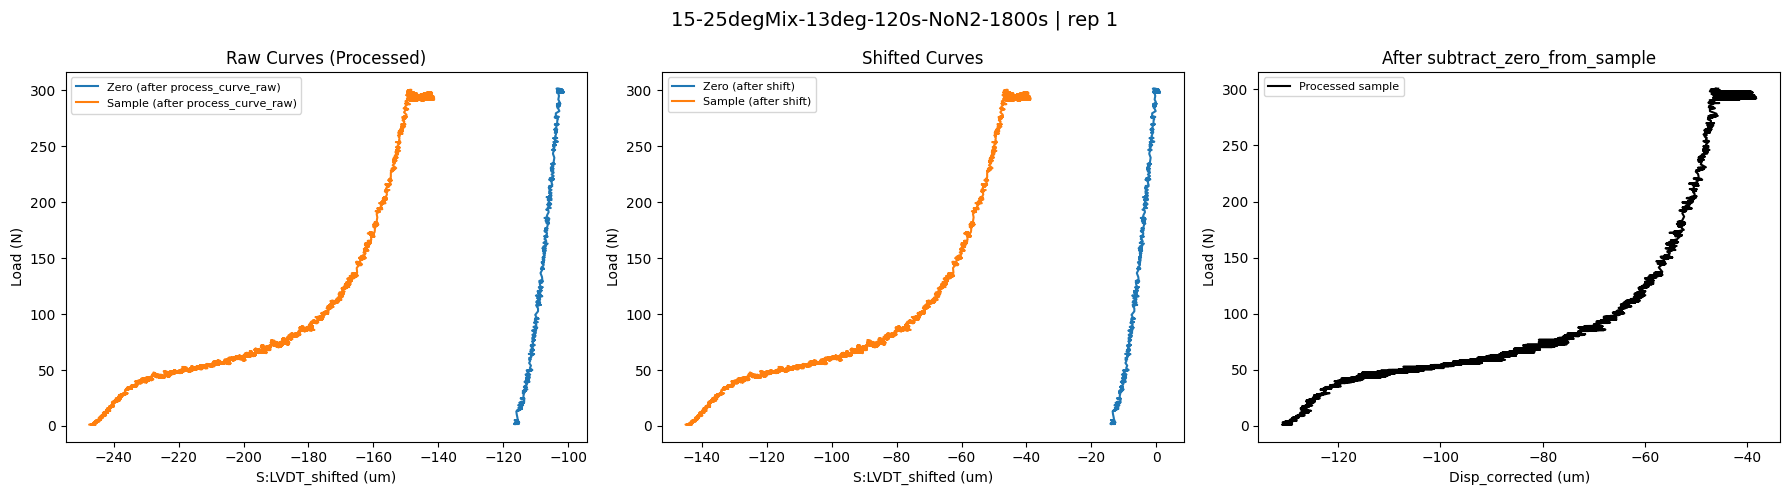

Average Standard Deviation: 57.000745351244696
Cutoff = 0.27713074200040644
PW + Double: 0.06869829570940361
Piecewise Chosen! 0.07547065841017499 | Drop Calculation: 0.09345477037062051
Cutoff = 0.27713074200040644
{'name': '15-25degMix-13deg-120s-NoN2-1800s | rep 1', 'Trial': 'sample 24', 'Thickness': np.float64(129.66699999999997), 'Elastic Modulus': np.float64(252.76402174435322), 'Yield Strength': np.float64(20.172112268468872), 'Changepoint': np.float64(0.5411060666154259), 'Slope Plateau': np.float64(48.01758962858205), 'Slope Densification': np.float64(954.5239695671173), 'Creep Strain': np.float64(0.06312074952757973), 'Strain at 50 bar': 0.49211542132354225, 'Strain at 80 bar': 0.5768140068922029, 'Strain at 150 bar': 0.6482313640357547, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.000745351244696)}


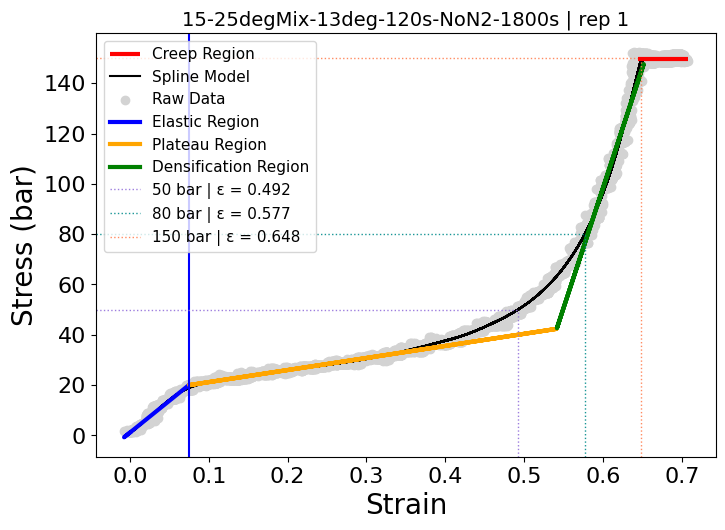

Score: 88/100 → PASS
  elastic_r2                     14/15  R²=0.950
  yield_accuracy                  4/10  |linear-GAM|=1.06 bar (5.5%)
  elastic_modulus                 5/5  E=252.8 bar
  junction_continuity            14/15  gap=0.8%
  plateau_flatness                2/5  slope/E=0.190
  plateau_r2_start                9/10  R²(first 40%)=0.932
  slope_ordering                  8/8  densif=954.5 > plateau=48.0
  densification_r2                2/2  R²=0.910
  elastic_vs_plateau             10/10  E=252.8 > slope=48.0
  breakpoint_order                5/5  bp1=0.075 < cp=0.541 < max=0.651
  densif_vs_elastic               5/5  densif/E=3.78
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=63.3 vs creep=149.8


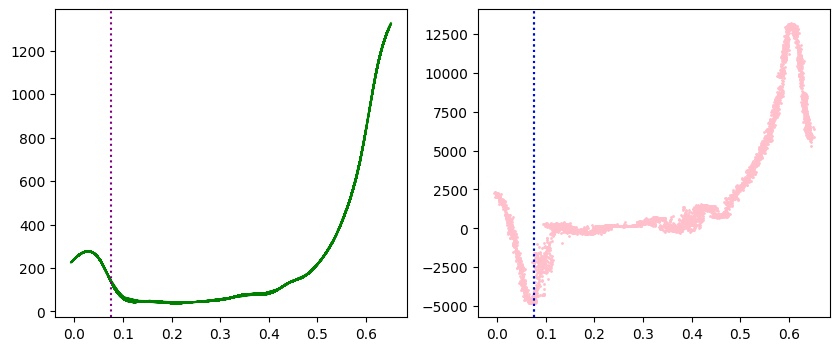

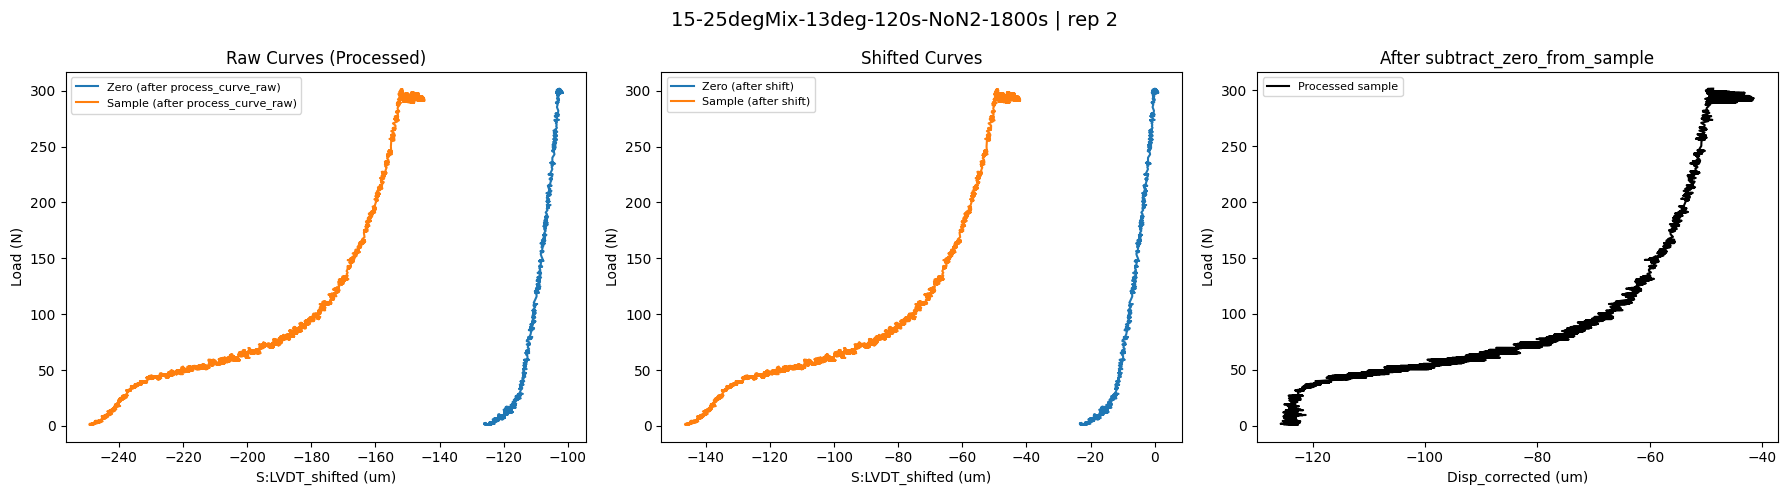

Average Standard Deviation: 57.203776686554306
Cutoff = 0.2446240219143372
PW + Double: 0.03167987688785933
Piecewise Chosen! 0.0330204443172402 | Drop Calculation: 0.04008937010821967
Cutoff = 0.2446240219143372
{'name': '15-25degMix-13deg-120s-NoN2-1800s | rep 2', 'Trial': 'sample 25', 'Thickness': np.float64(123.80844376873661), 'Elastic Modulus': np.float64(457.21589604368586), 'Yield Strength': np.float64(19.684791255592973), 'Changepoint': np.float64(0.5104890545348384), 'Slope Plateau': np.float64(52.4333317815799), 'Slope Densification': np.float64(1031.9647962164026), 'Creep Strain': np.float64(0.0656200780027103), 'Strain at 50 bar': 0.4529874894996897, 'Strain at 80 bar': 0.5385668698794221, 'Strain at 150 bar': 0.609517393990987, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.203776686554306)}


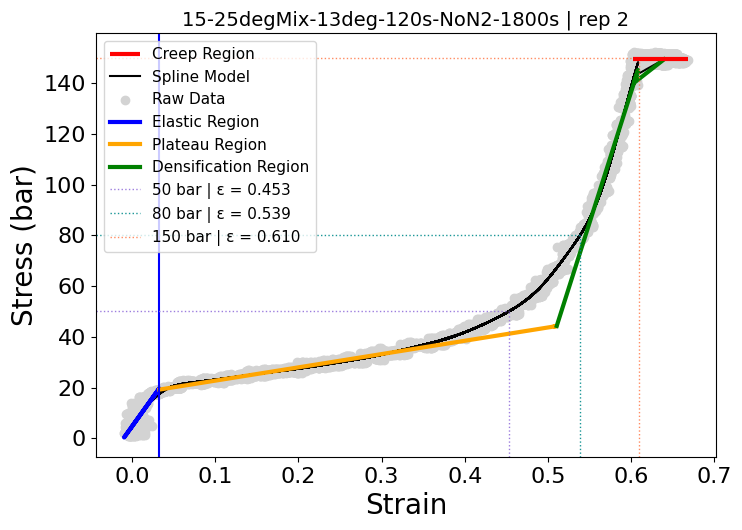

Score: 75/100 → PASS
  elastic_r2                      8/15  R²=0.505
  yield_accuracy                  0/10  |linear-GAM|=1.98 bar (11.2%)
  elastic_modulus                 5/5  E=457.2 bar
  junction_continuity            11/15  gap=2.4%
  plateau_flatness                2/5  slope/E=0.115
  plateau_r2_start                9/10  R²(first 40%)=0.915
  slope_ordering                  8/8  densif=1032.0 > plateau=52.4
  densification_r2                2/2  R²=0.866
  elastic_vs_plateau             10/10  E=457.2 > slope=52.4
  breakpoint_order                5/5  bp1=0.033 < cp=0.510 < max=0.639
  densif_vs_elastic               5/5  densif/E=2.26
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=67.1 vs creep=149.4


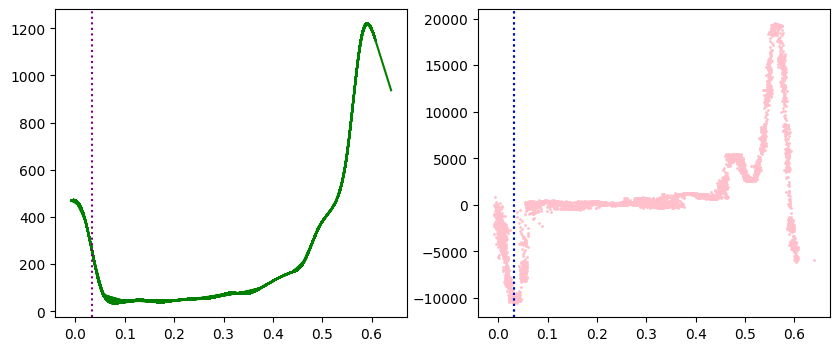

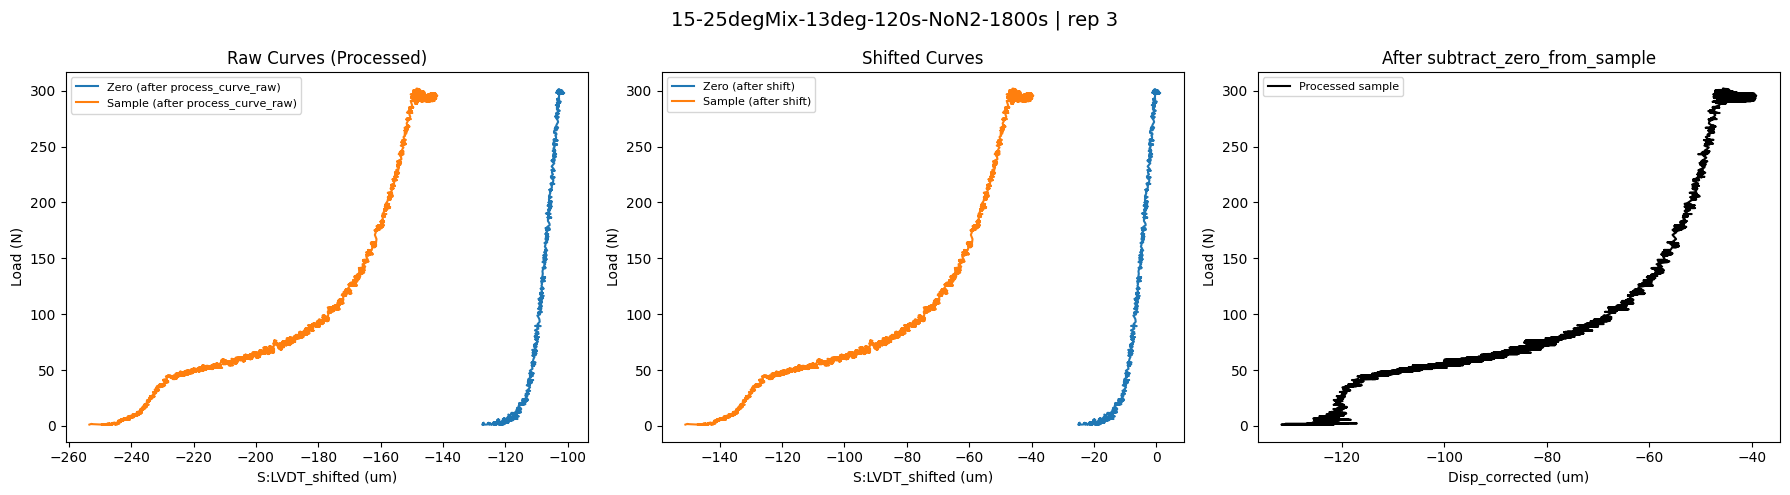

Average Standard Deviation: 56.99820998775487
Cutoff = 0.1825887467672634
PW + Double: 0.03266567819054507
Piecewise Chosen! 0.03316459385177365 | Drop Calculation: 0.037540043812723155
Cutoff = 0.1825887467672634
{'name': '15-25degMix-13deg-120s-NoN2-1800s | rep 3', 'Trial': 'sample 26', 'Thickness': np.float64(126.26339999999998), 'Elastic Modulus': np.float64(321.1646283222395), 'Yield Strength': np.float64(22.26975035524196), 'Changepoint': np.float64(0.46864632216144825), 'Slope Plateau': np.float64(50.550835937816736), 'Slope Densification': np.float64(877.7363296188846), 'Creep Strain': np.float64(0.0607598717681751), 'Strain at 50 bar': 0.40946700261652225, 'Strain at 80 bar': 0.504894049854746, 'Strain at 150 bar': 0.58241890596844, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(56.99820998775487)}


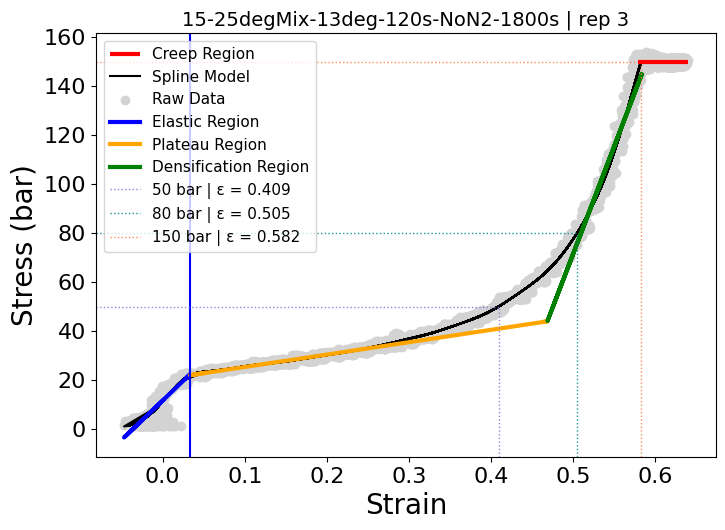

Score: 89/100 → PASS
  elastic_r2                     12/15  R²=0.782
  yield_accuracy                  8/10  |linear-GAM|=0.39 bar (1.8%)
  elastic_modulus                 5/5  E=321.2 bar
  junction_continuity            13/15  gap=1.5%
  plateau_flatness                2/5  slope/E=0.157
  plateau_r2_start                9/10  R²(first 40%)=0.921
  slope_ordering                  8/8  densif=877.7 > plateau=50.6
  densification_r2                2/2  R²=0.904
  elastic_vs_plateau             10/10  E=321.2 > slope=50.6
  breakpoint_order                5/5  bp1=0.033 < cp=0.469 < max=0.584
  densif_vs_elastic               5/5  densif/E=2.73
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=64.5 vs creep=149.7
Condition: 17-13deg-120s-N2-1800s | pairs: 3


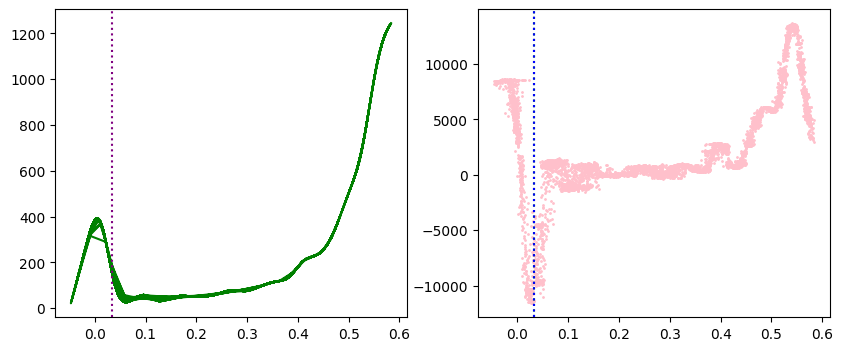

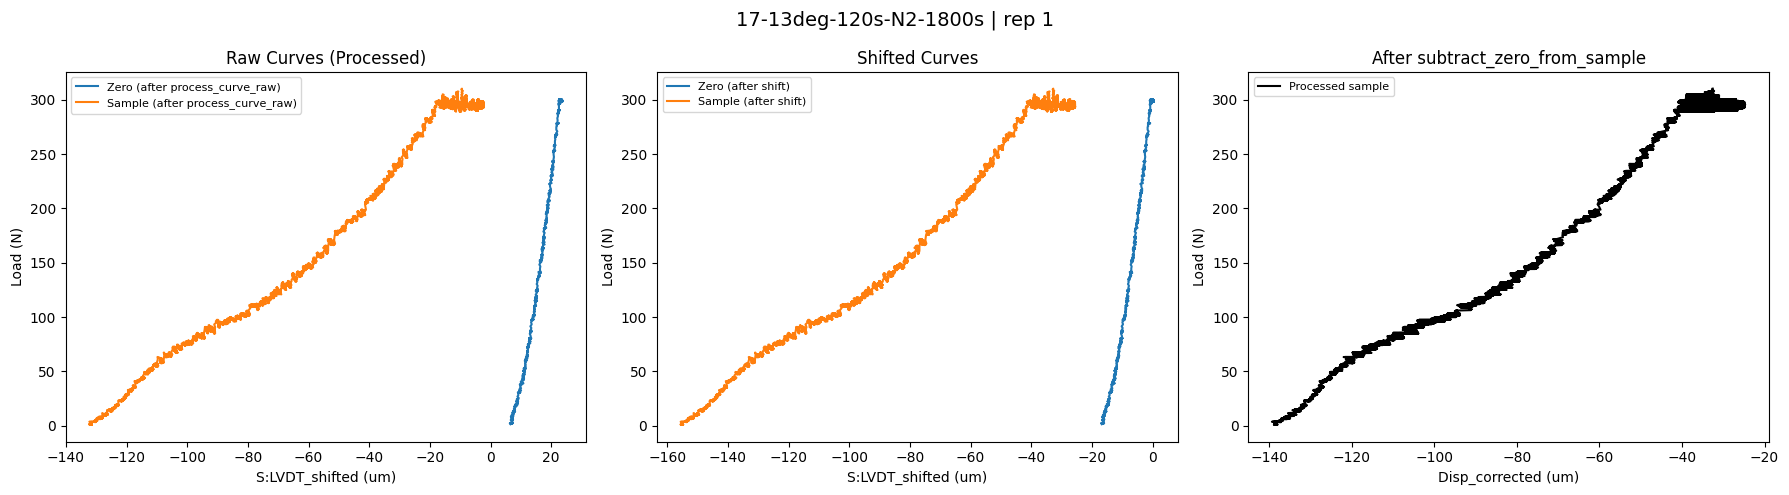

Average Standard Deviation: 51.315875394423344
Cutoff = 0.2
PW + Double: 0.12042553914477175
Piecewise Chosen! 0.13000671916436923 | Drop Calculation: 0.1282056746146956
Cutoff = 0.2
{'name': '17-13deg-120s-N2-1800s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(138.6586), 'Elastic Modulus': np.float64(248.59819551596325), 'Yield Strength': np.float64(30.293406144039267), 'Changepoint': np.float64(0.4566008630905179), 'Slope Plateau': np.float64(116.77641963319337), 'Slope Densification': np.float64(302.58812660416527), 'Creep Strain': np.float64(0.10007153184003803), 'Strain at 50 bar': 0.2877606230950699, 'Strain at 80 bar': 0.4721389185859859, 'Strain at 150 bar': 0.7270891901372185, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(51.315875394423344)}


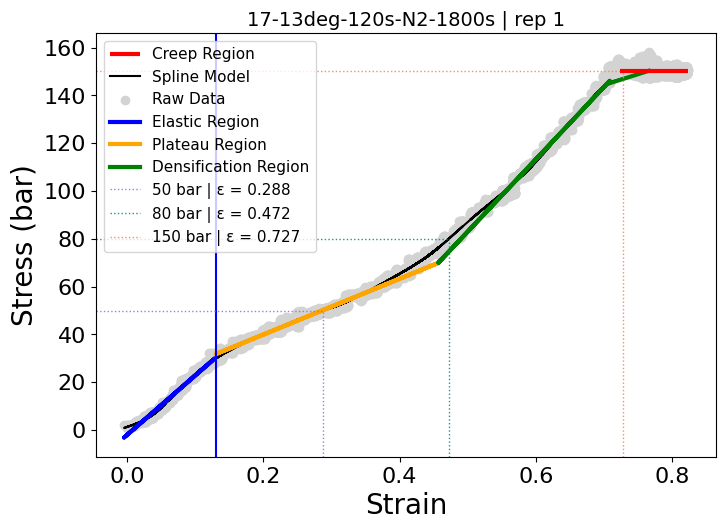

Score: 87/100 → PASS
  elastic_r2                     15/15  R²=0.980
  yield_accuracy                  9/10  |linear-GAM|=0.32 bar (1.1%)
  elastic_modulus                 5/5  E=248.6 bar
  junction_continuity             8/15  gap=4.9%
  plateau_flatness                1/5  slope/E=0.470
  plateau_r2_start                9/10  R²(first 40%)=0.939
  slope_ordering                  8/8  densif=302.6 > plateau=116.8
  densification_r2                2/2  R²=0.980
  elastic_vs_plateau             10/10  E=248.6 > slope=116.8
  breakpoint_order                5/5  bp1=0.130 < cp=0.457 < max=0.765
  densif_vs_elastic               5/5  densif/E=1.22
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=76.2 vs creep=150.3


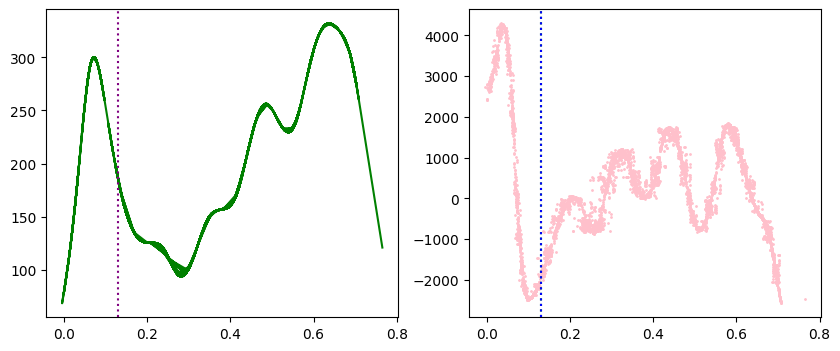

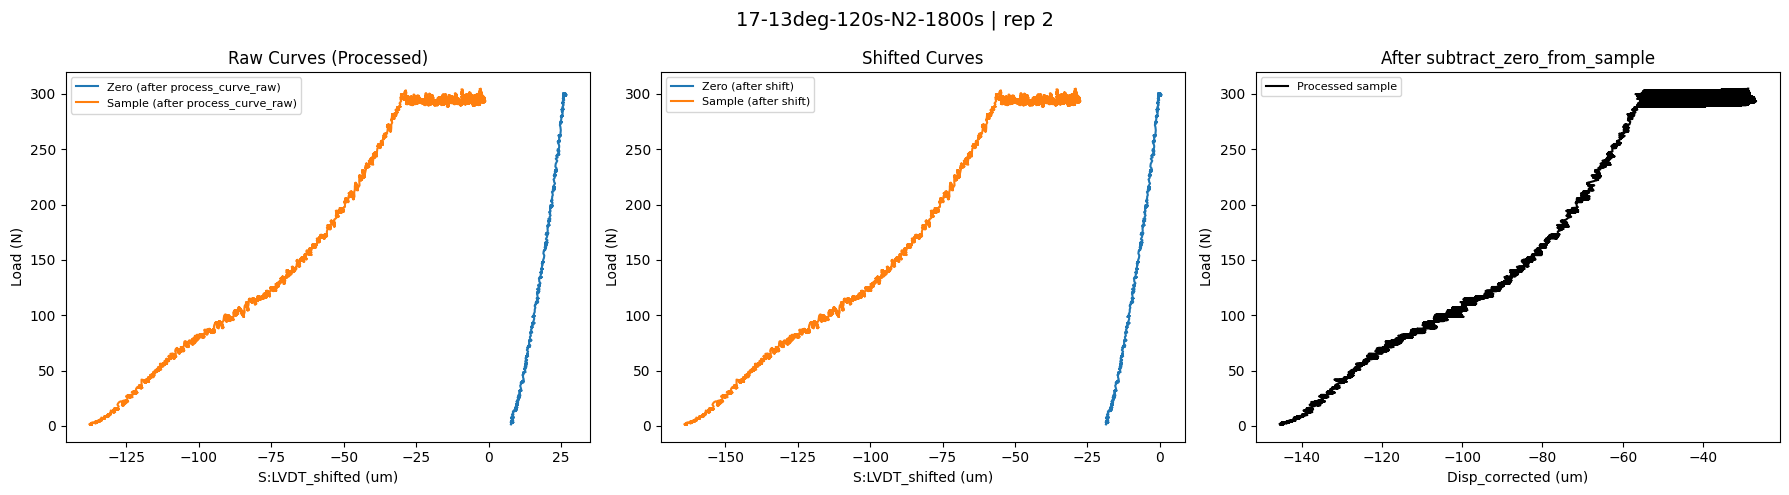

Average Standard Deviation: 52.77407857079128
Cutoff = 0.7259476408698076
PW + Double: 0.4716864921784523
Drop Chosen! 0.16405693583532607 | Piecewise Calculation: 0.45267822032002764
Cutoff = 0.7259476408698076
{'name': '17-13deg-120s-N2-1800s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(145.3388), 'Elastic Modulus': np.float64(219.41191939879758), 'Yield Strength': np.float64(33.58944930387414), 'Changepoint': np.float64(0.4403786530826514), 'Slope Plateau': np.float64(142.3367974243309), 'Slope Densification': np.float64(426.63694684929135), 'Creep Strain': np.float64(0.19294987732211188), 'Strain at 50 bar': 0.27865652636662963, 'Strain at 80 bar': 0.43860286244917623, 'Strain at 150 bar': 0.6173551604220151, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(52.77407857079128)}


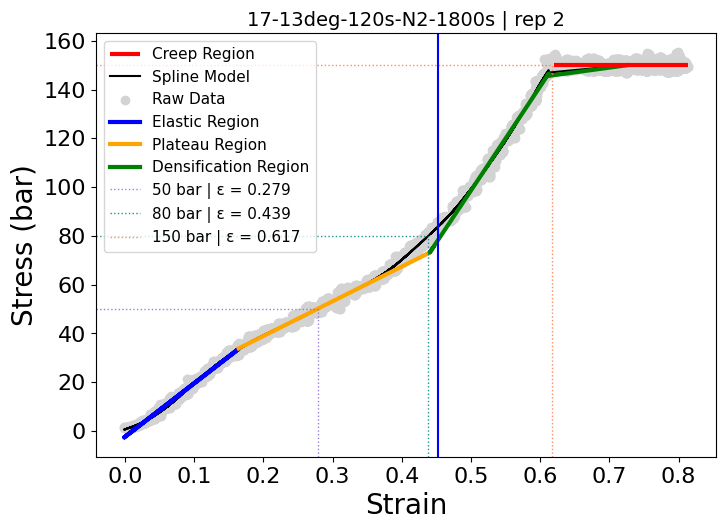

Score: 94/100 → PASS
  elastic_r2                     15/15  R²=0.987
  yield_accuracy                 10/10  |linear-GAM|=0.14 bar (0.4%)
  elastic_modulus                 5/5  E=219.4 bar
  junction_continuity            14/15  gap=0.6%
  plateau_flatness                1/5  slope/E=0.649
  plateau_r2_start                9/10  R²(first 40%)=0.941
  slope_ordering                  8/8  densif=426.6 > plateau=142.3
  densification_r2                2/2  R²=0.978
  elastic_vs_plateau             10/10  E=219.4 > slope=142.3
  breakpoint_order                5/5  bp1=0.164 < cp=0.440 < max=0.726
  densif_vs_elastic               5/5  densif/E=1.94
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=80.5 vs creep=150.0


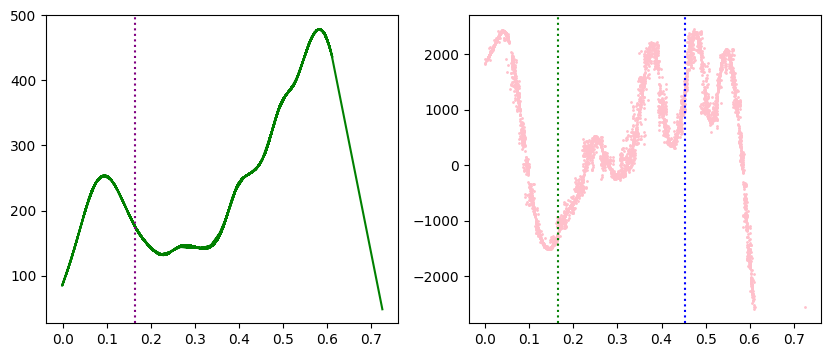

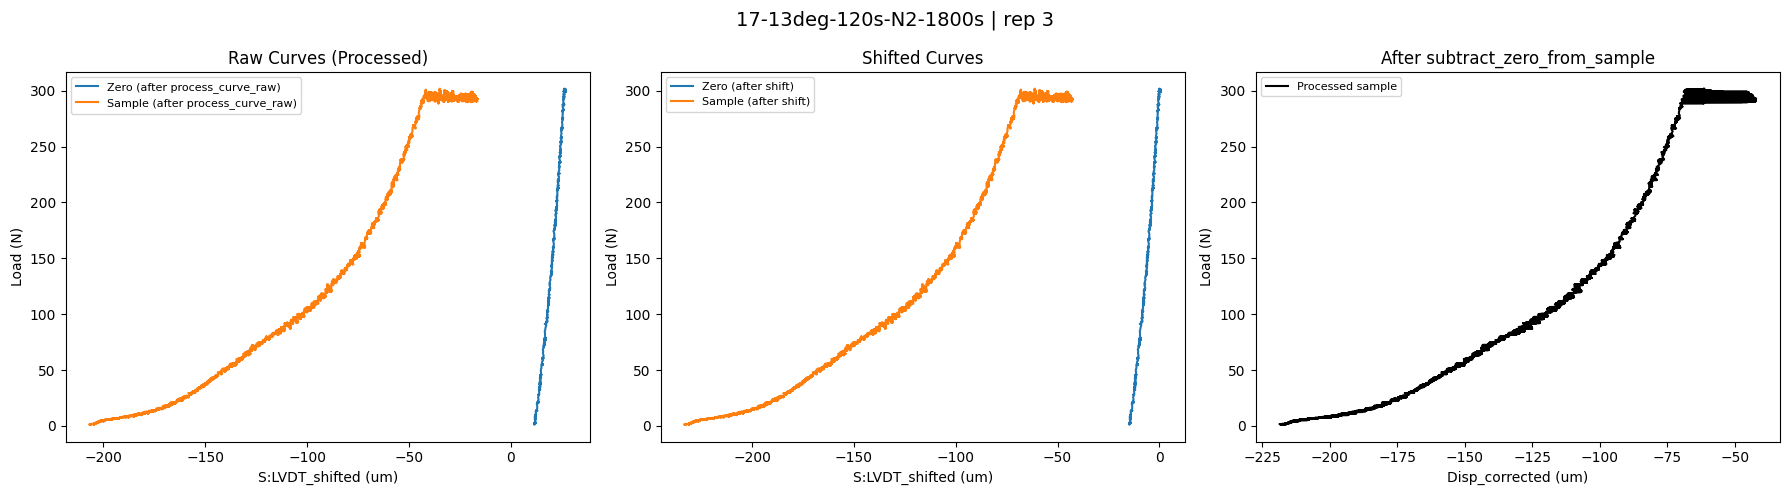

Average Standard Deviation: 58.95160346013324
Cutoff = 0.0895156073943445
PW + Double: 0.013958830995577386
Piecewise Chosen! 0.014974175294313536 | Drop Calculation: 0.03810924775340774
Cutoff = 0.0895156073943445
{'name': '17-13deg-120s-N2-1800s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(217.932), 'Elastic Modulus': np.float64(83.19833055819198), 'Yield Strength': np.float64(2.209271622061153), 'Changepoint': np.float64(0.48664476489327274), 'Slope Plateau': np.float64(58.459240693341656), 'Slope Densification': np.float64(617.7770672780813), 'Creep Strain': np.float64(0.11864801864801866), 'Strain at 50 bar': 0.4376683248369936, 'Strain at 80 bar': 0.5567171188254738, 'Strain at 150 bar': 0.6832493666232815, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(58.95160346013324)}


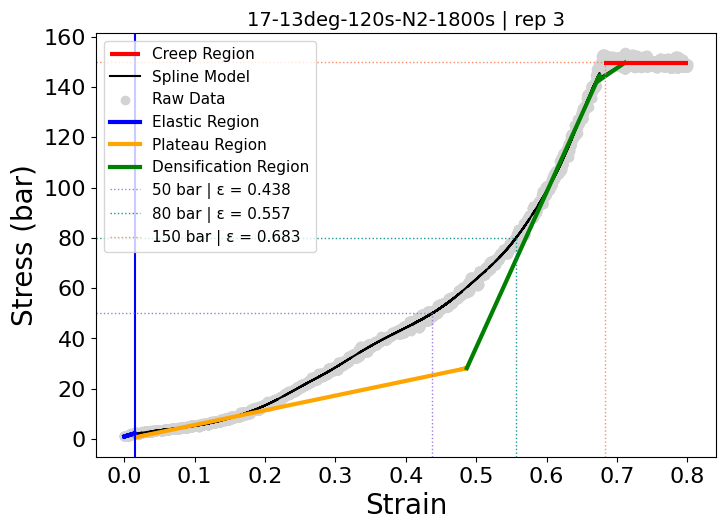

Score: 67/100 → PASS
  elastic_r2                     13/15  R²=0.851
  yield_accuracy                  0/10  |linear-GAM|=0.22 bar (10.9%)
  elastic_modulus                 5/5  E=83.2 bar
  junction_continuity             0/15  gap=73.4%
  plateau_flatness                1/5  slope/E=0.703
  plateau_r2_start                9/10  R²(first 40%)=0.918
  slope_ordering                  8/8  densif=617.8 > plateau=58.5
  densification_r2                1/2  R²=0.749
  elastic_vs_plateau             10/10  E=83.2 > slope=58.5
  breakpoint_order                5/5  bp1=0.015 < cp=0.487 < max=0.711
  densif_vs_elastic               5/5  densif/E=7.43
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=60.3 vs creep=149.7
Condition: 17-13deg-120s-NoN2-1800s | pairs: 6


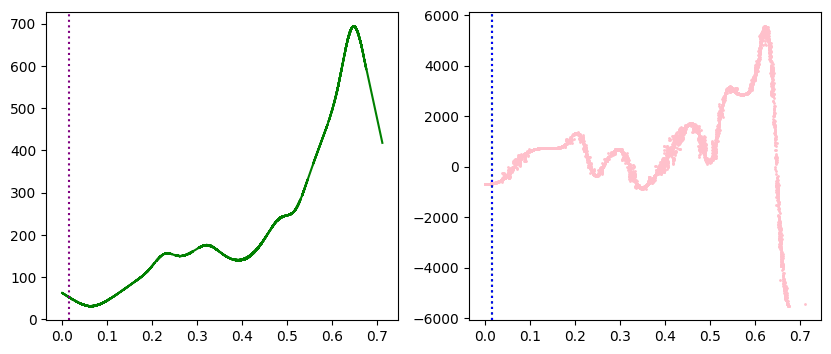

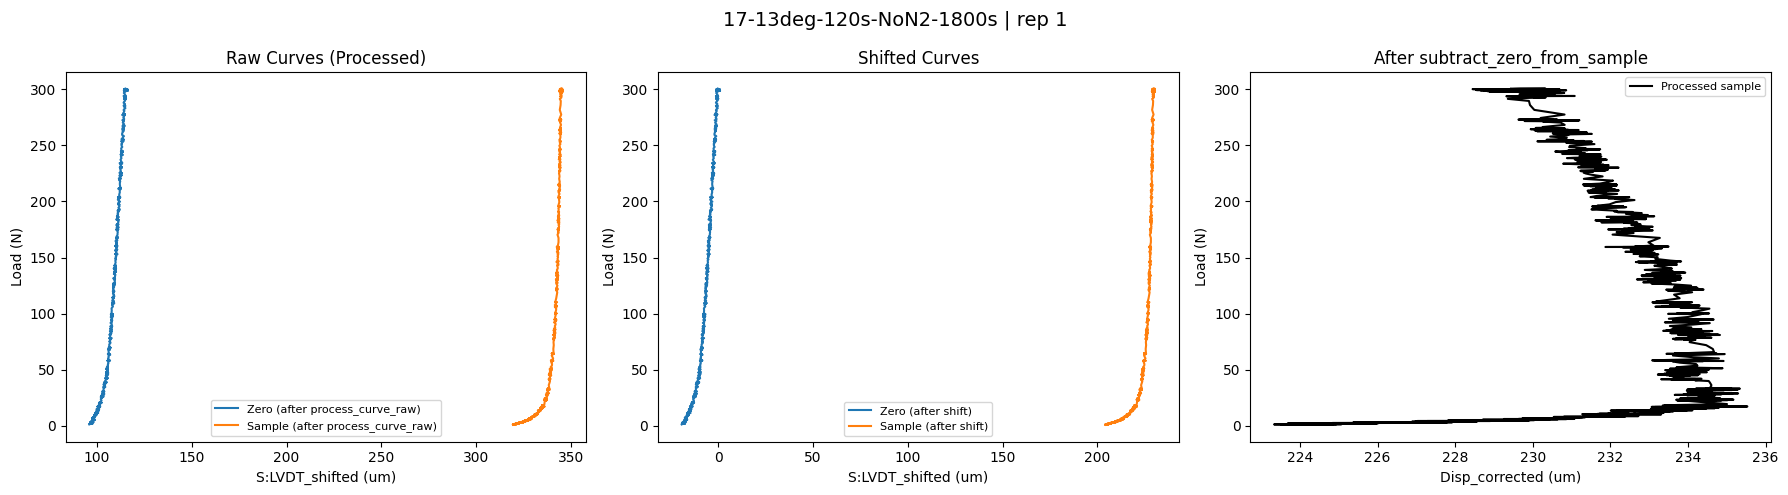

Average Standard Deviation: 52.823431495481614
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 1 (thickness=-223.9 µm — no membrane)


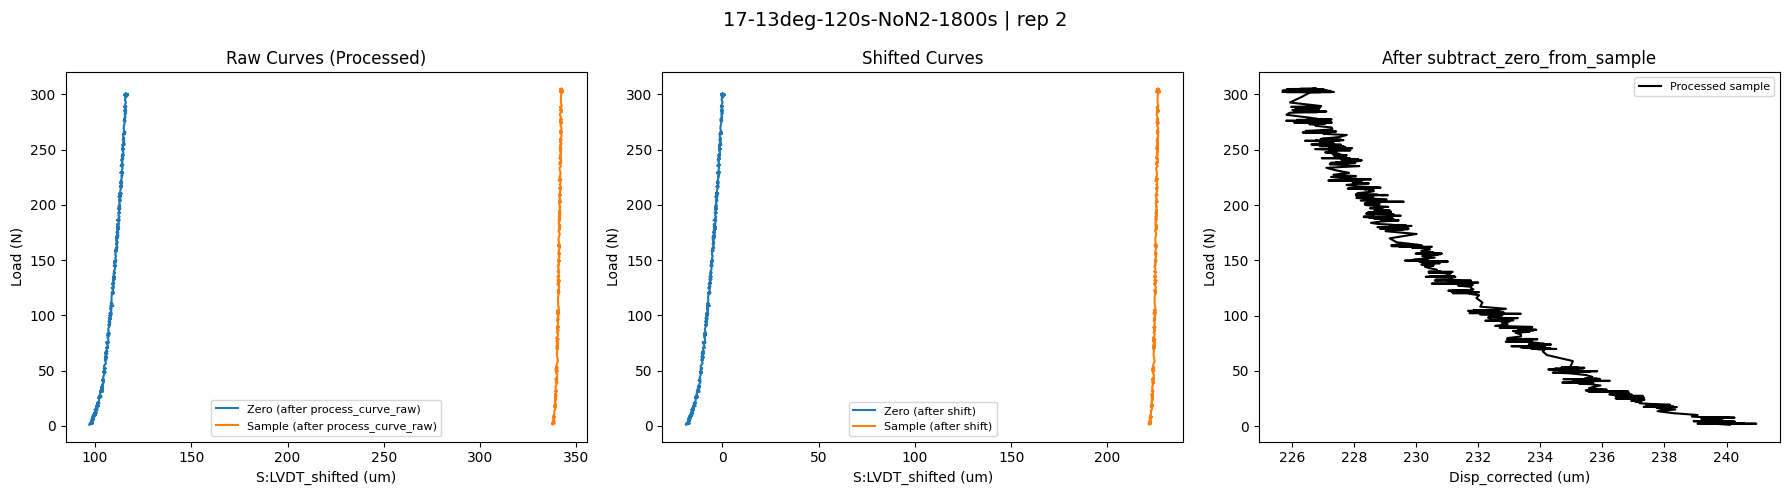

Average Standard Deviation: 38.31915443694229
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 2 (thickness=-240.1 µm — no membrane)


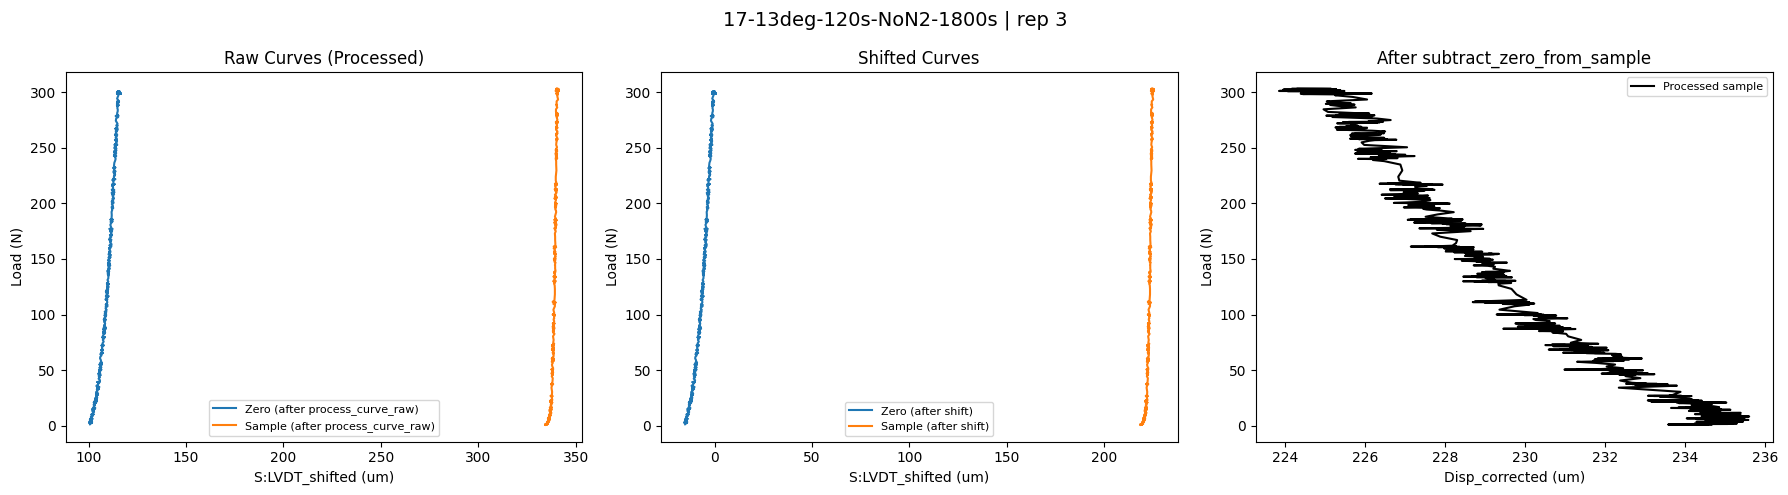

Average Standard Deviation: 38.35309078713445
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 3 (thickness=-233.8 µm — no membrane)


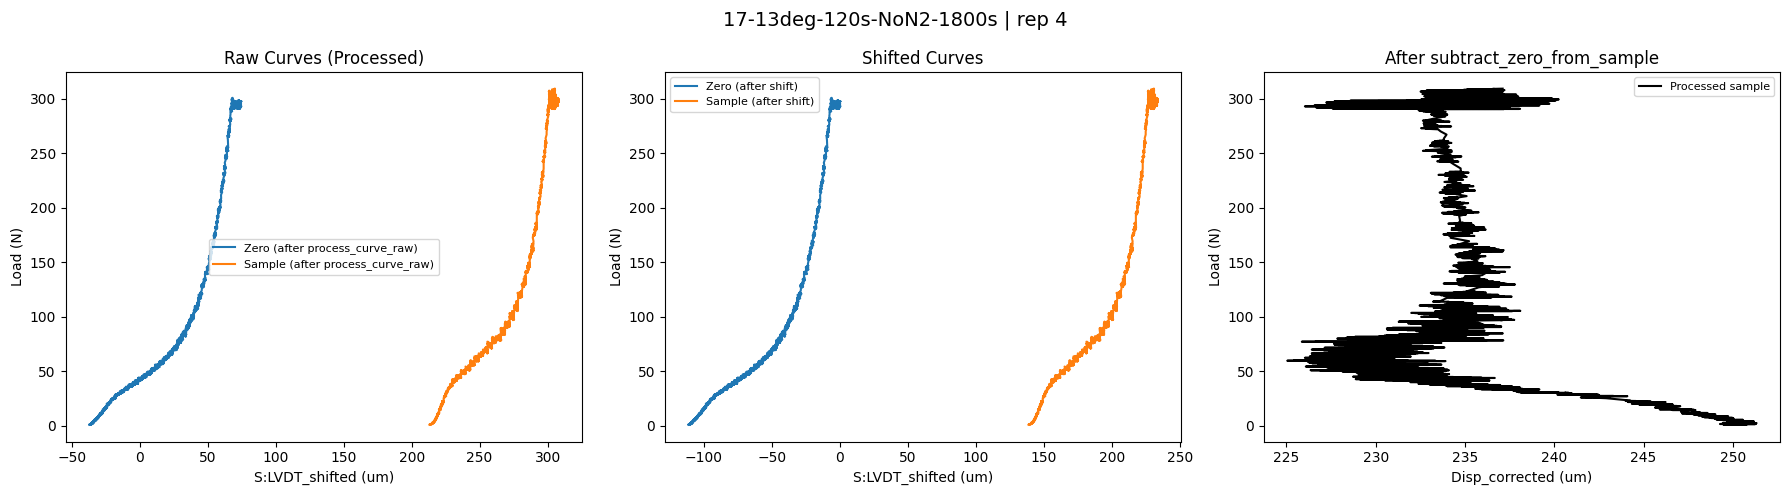

Average Standard Deviation: 55.92130416870417
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 4 (thickness=-249.8 µm — no membrane)


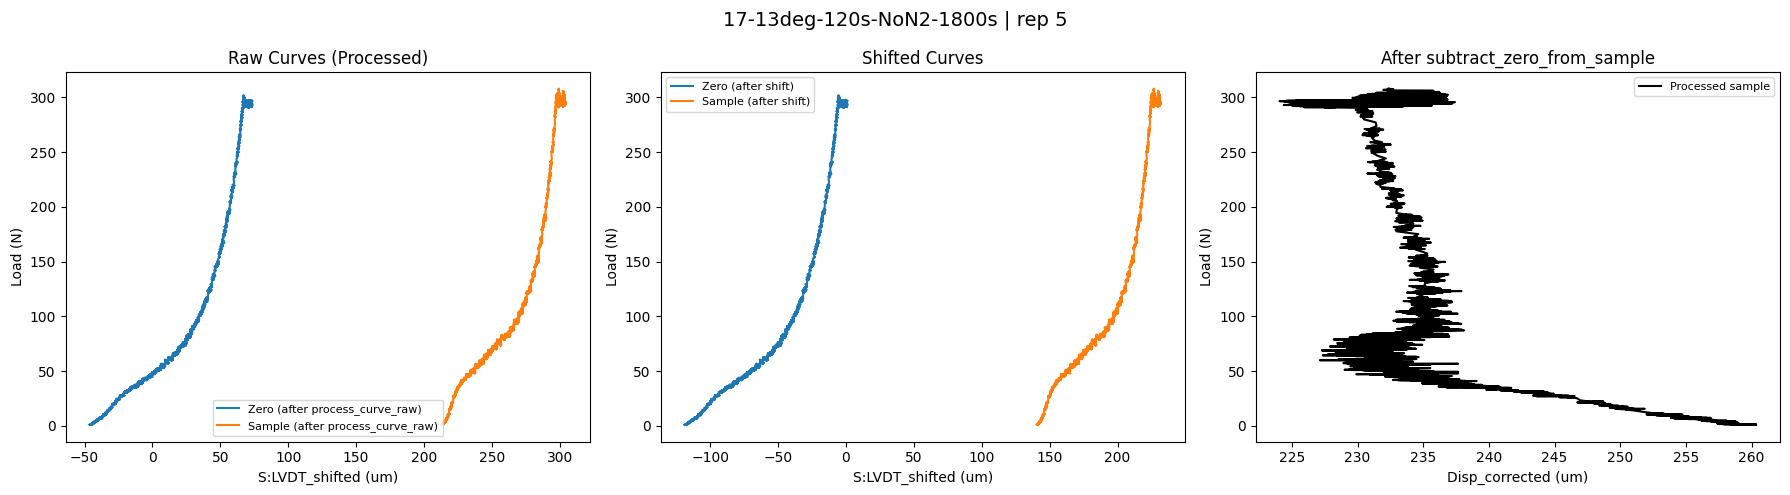

Average Standard Deviation: 55.75813959750418
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 5 (thickness=-260.3 µm — no membrane)


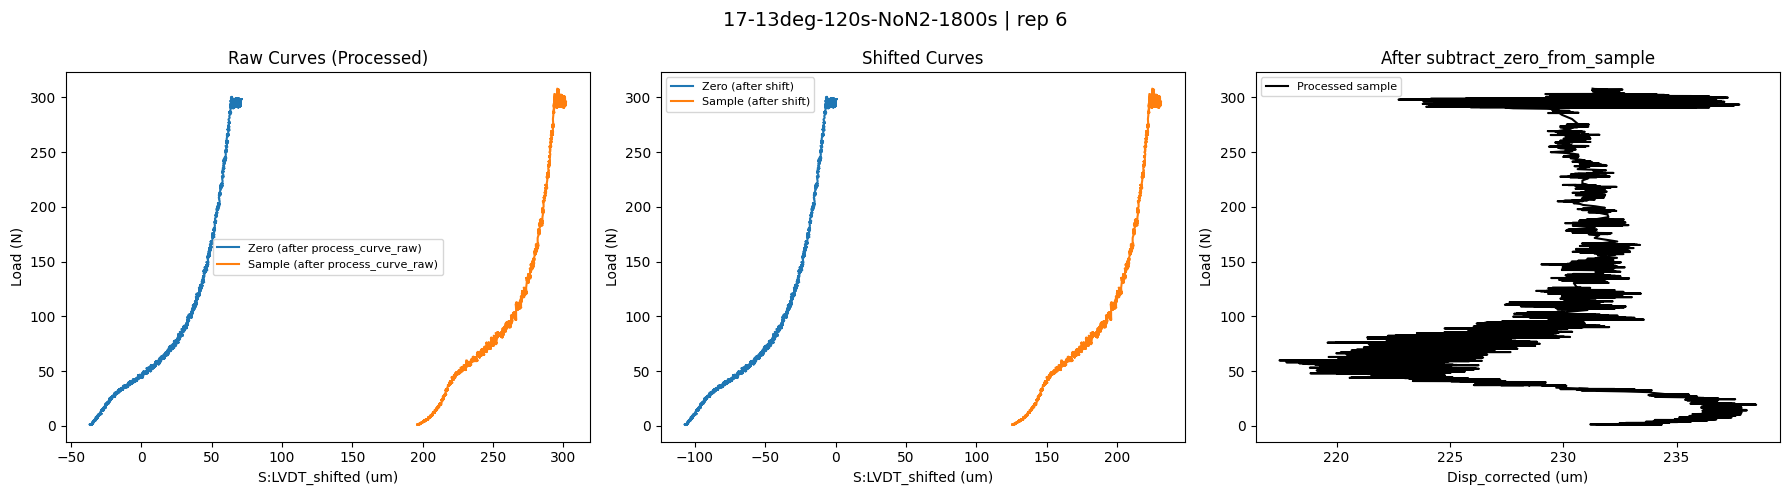

Average Standard Deviation: 57.57987800694638
Skipping GAM for 17-13deg-120s-NoN2-1800s | rep 6 (thickness=-232.7 µm — no membrane)
Condition: 17-13deg-60s-N2-1800s | pairs: 3


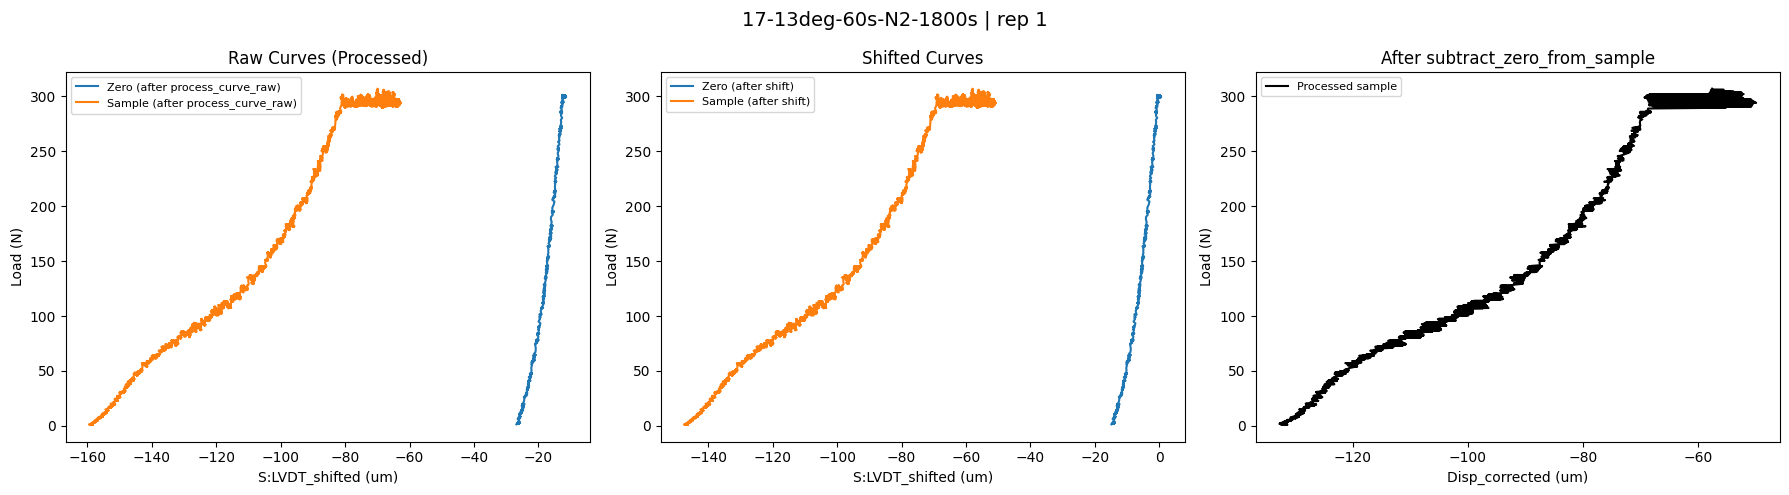

Average Standard Deviation: 51.92686475501387
Cutoff = 0.5814215905441266
PW + Double: 0.3906406029622377
Drop Chosen! 0.0883629042874265 | Piecewise Calculation: 0.36345612815860323
Cutoff = 0.5814215905441266
{'name': '17-13deg-60s-N2-1800s | rep 1', 'Trial': 'sample 9', 'Thickness': np.float64(132.1816), 'Elastic Modulus': np.float64(320.7446804378671), 'Yield Strength': np.float64(28.16991298622014), 'Changepoint': np.float64(0.34667224643772715), 'Slope Plateau': np.float64(146.0284440226058), 'Slope Densification': np.float64(581.3288711326327), 'Creep Strain': np.float64(0.14079997316387916), 'Strain at 50 bar': 0.21951098277243286, 'Strain at 80 bar': 0.3485813067300867, 'Strain at 150 bar': nan, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(51.92686475501387)}


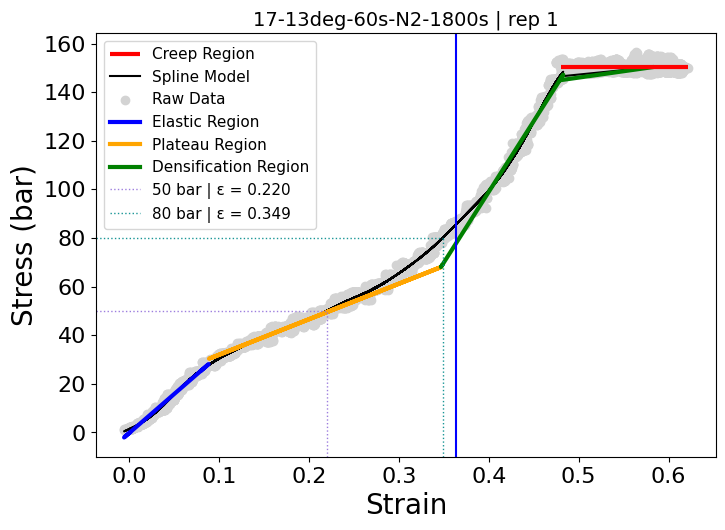

Score: 83/100 → PASS
  elastic_r2                     15/15  R²=0.979
  yield_accuracy                  9/10  |linear-GAM|=0.32 bar (1.1%)
  elastic_modulus                 5/5  E=320.7 bar
  junction_continuity             4/15  gap=7.5%
  plateau_flatness                1/5  slope/E=0.455
  plateau_r2_start                9/10  R²(first 40%)=0.924
  slope_ordering                  8/8  densif=581.3 > plateau=146.0
  densification_r2                2/2  R²=0.951
  elastic_vs_plateau             10/10  E=320.7 > slope=146.0
  breakpoint_order                5/5  bp1=0.088 < cp=0.347 < max=0.581
  densif_vs_elastic               5/5  densif/E=1.81
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=79.3 vs creep=150.2


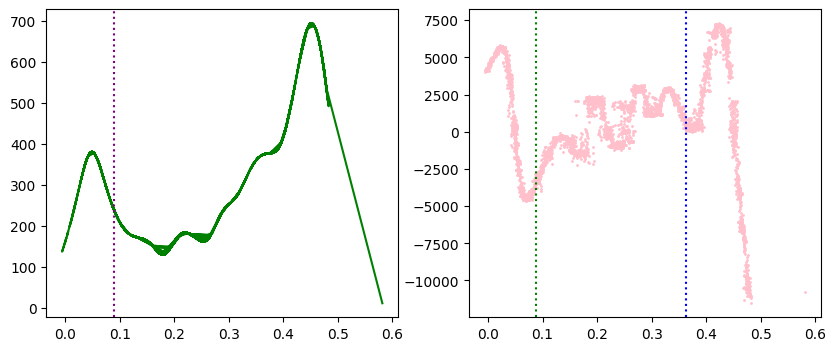

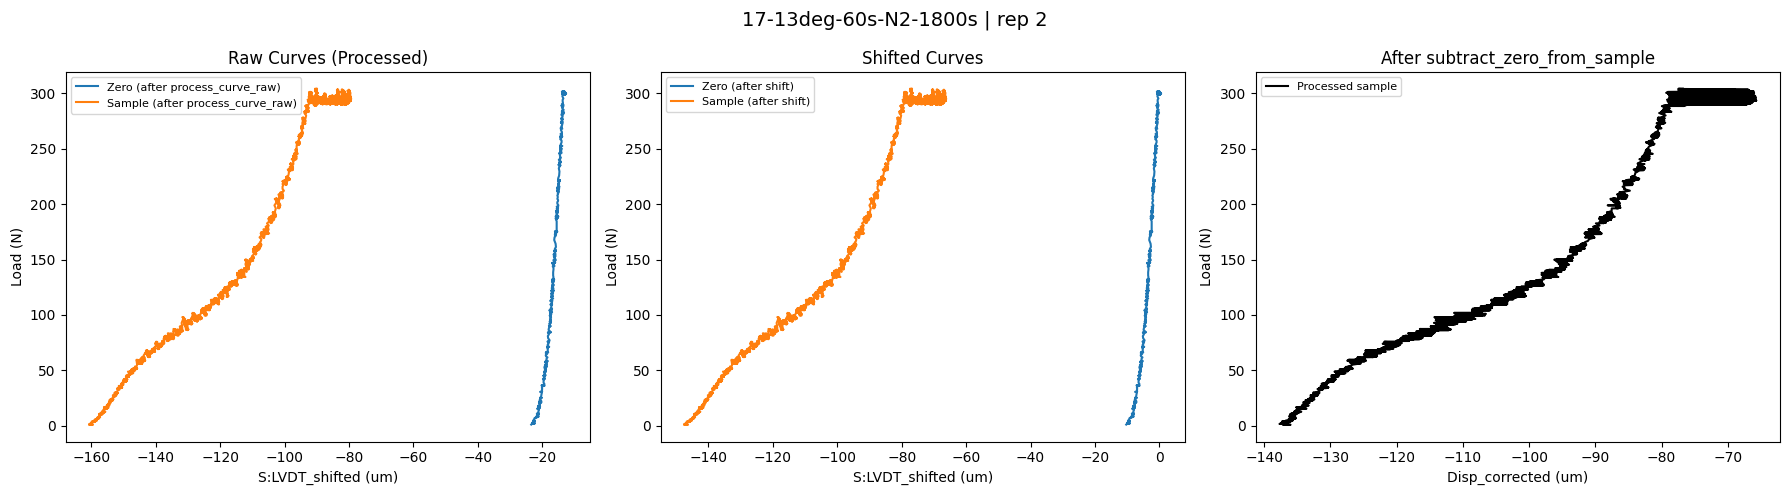

Average Standard Deviation: 50.73465942749341
Cutoff = 0.19337277195605718
PW + Double: 0.07436584593081579
Piecewise Chosen! 0.07664332048159843 | Drop Calculation: 0.08409231535755875
Cutoff = 0.19337277195605718
{'name': '17-13deg-60s-N2-1800s | rep 2', 'Trial': 'sample 10', 'Thickness': np.float64(136.3472), 'Elastic Modulus': np.float64(377.06989910123264), 'Yield Strength': np.float64(28.60164956785721), 'Changepoint': np.float64(0.33572633929630485), 'Slope Plateau': np.float64(163.02030081252775), 'Slope Densification': np.float64(791.0523451214107), 'Creep Strain': np.float64(0.09724292101341292), 'Strain at 50 bar': 0.20467851820310812, 'Strain at 80 bar': 0.32595273578880124, 'Strain at 150 bar': 0.4321530060993486, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(50.73465942749341)}


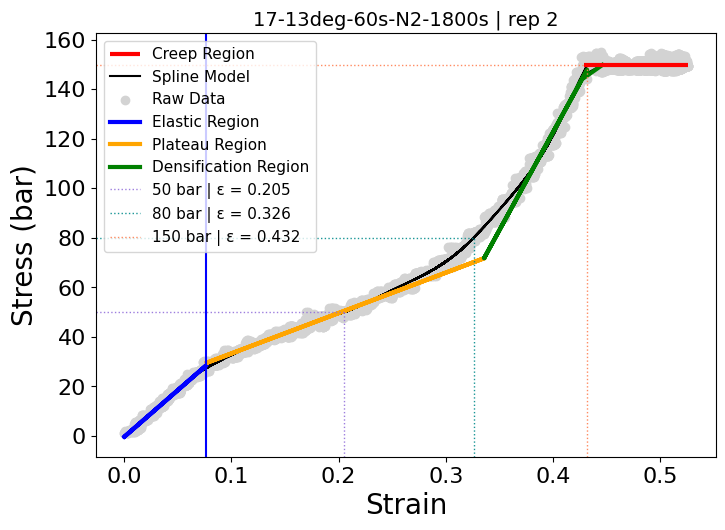

Score: 87/100 → PASS
  elastic_r2                     15/15  R²=0.986
  yield_accuracy                  6/10  |linear-GAM|=1.06 bar (3.9%)
  elastic_modulus                 5/5  E=377.1 bar
  junction_continuity            10/15  gap=3.3%
  plateau_flatness                1/5  slope/E=0.432
  plateau_r2_start               10/10  R²(first 40%)=0.952
  slope_ordering                  8/8  densif=791.1 > plateau=163.0
  densification_r2                2/2  R²=0.922
  elastic_vs_plateau             10/10  E=377.1 > slope=163.0
  breakpoint_order                5/5  bp1=0.077 < cp=0.336 < max=0.446
  densif_vs_elastic               5/5  densif/E=2.10
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=84.5 vs creep=149.8


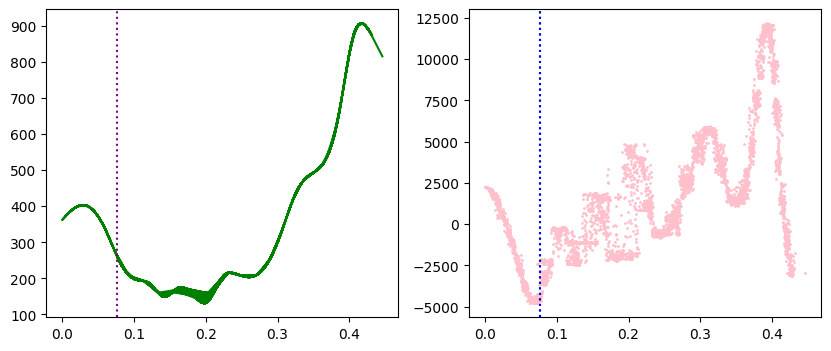

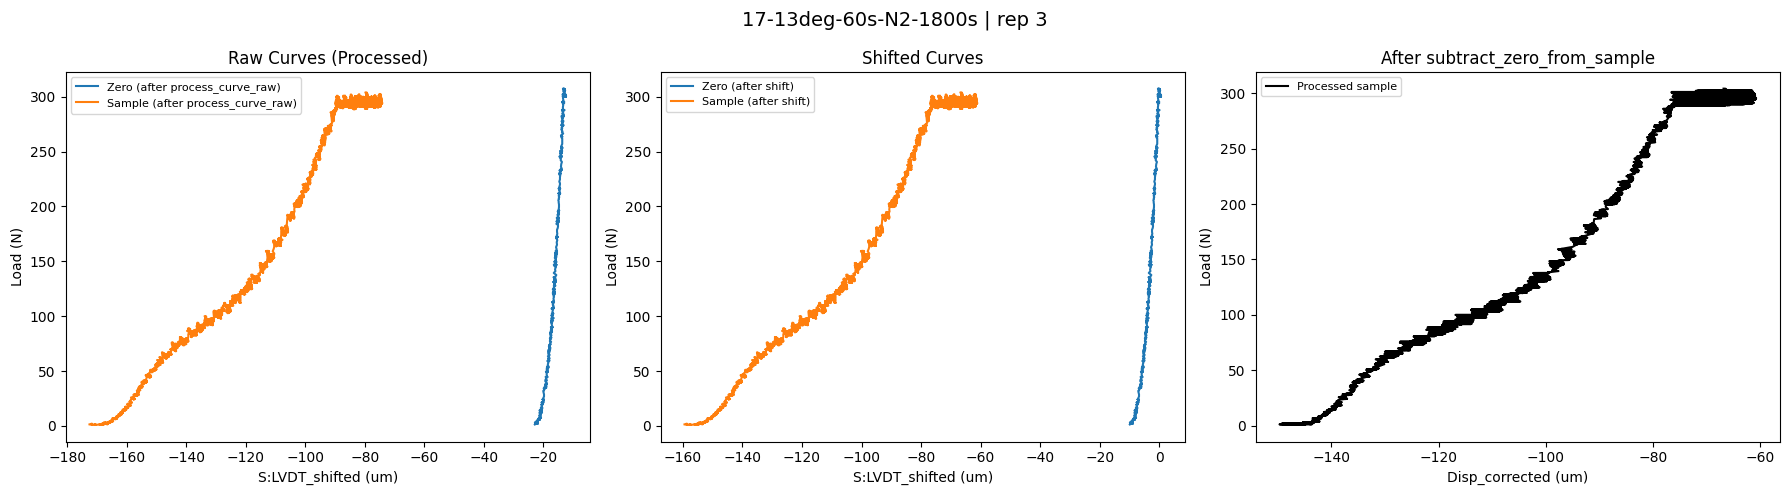

Average Standard Deviation: 51.05262842172016
Cutoff = -0.021671824248956972
pw regression failed (n_bp=1): xx must be a list of numbers with minimum length 3
PW + Double: None
Drop Chosen! 0.09889091812791133 | Piecewise Calculation: None
Cutoff = -0.021671824248956972
pw regression failed (n_bp=1): xx must be a list of numbers with minimum length 3
{'name': '17-13deg-60s-N2-1800s | rep 3', 'Trial': 'sample 11', 'Thickness': np.float64(147.72639999999998), 'Elastic Modulus': np.float64(324.49953516966906), 'Yield Strength': np.float64(31.567889038755066), 'Changepoint': np.float64(0.332482564653899), 'Slope Plateau': np.float64(175.86794238220247), 'Slope Densification': np.float64(586.4127788494334), 'Creep Strain': np.float64(0.10212915477688478), 'Strain at 50 bar': 0.20462897639856903, 'Strain at 80 bar': 0.3293305250922941, 'Strain at 150 bar': nan, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(51.05262842172016)}


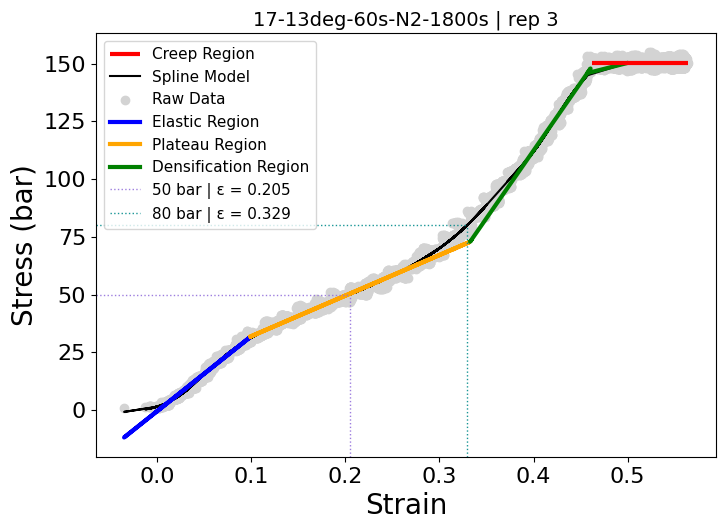

Score: 92/100 → PASS
  elastic_r2                     15/15  R²=0.980
  yield_accuracy                  8/10  |linear-GAM|=0.49 bar (1.6%)
  elastic_modulus                 5/5  E=324.5 bar
  junction_continuity            14/15  gap=0.5%
  plateau_flatness                1/5  slope/E=0.542
  plateau_r2_start                9/10  R²(first 40%)=0.935
  slope_ordering                  8/8  densif=586.4 > plateau=175.9
  densification_r2                2/2  R²=0.961
  elastic_vs_plateau             10/10  E=324.5 > slope=175.9
  breakpoint_order                5/5  bp1=0.099 < cp=0.332 < max=0.499
  densif_vs_elastic               5/5  densif/E=1.81
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=81.2 vs creep=150.2
Condition: 17-20deg-15s-NoN2-120s | pairs: 3


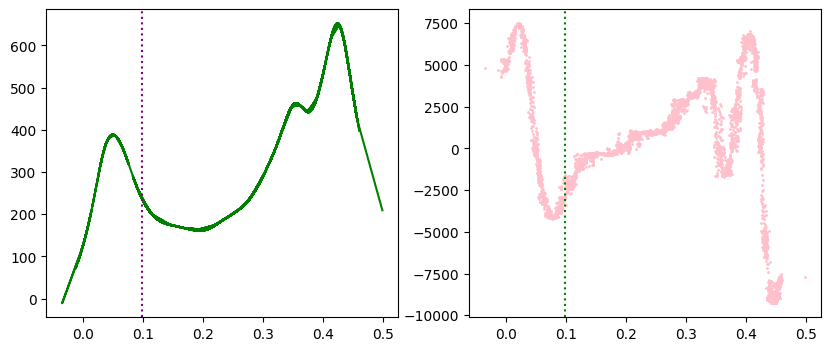

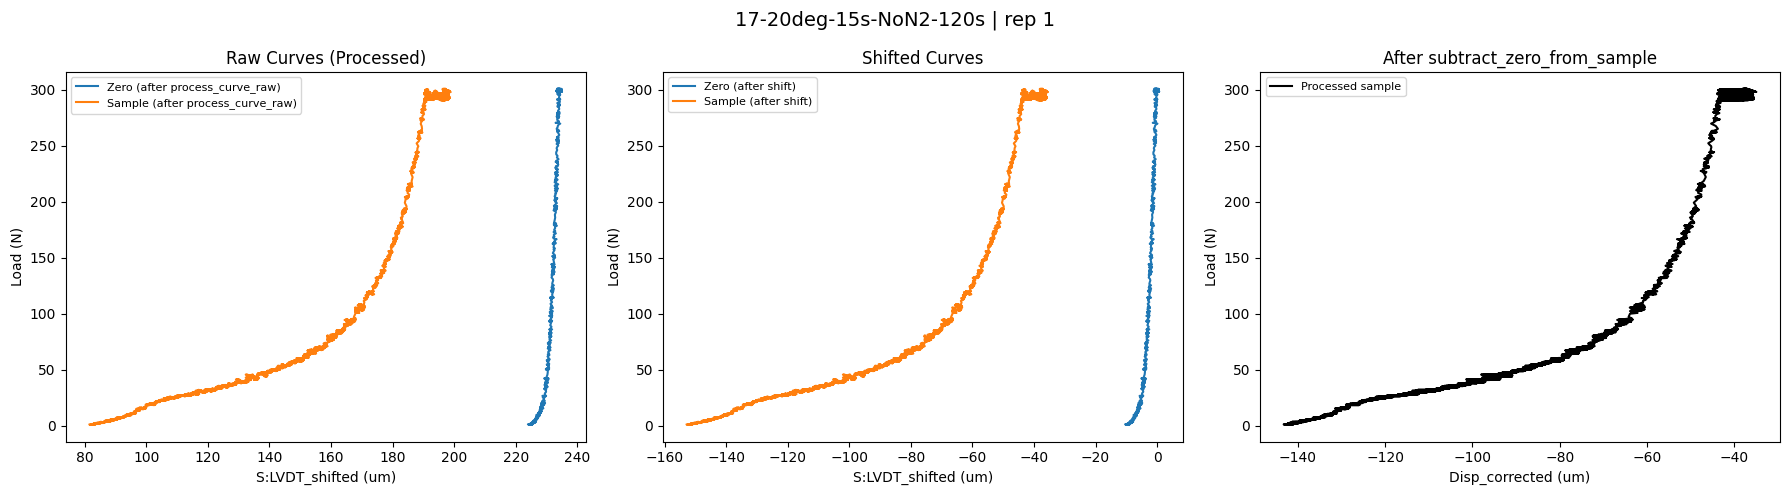

Average Standard Deviation: 61.30247107504307
Cutoff = 0.2524382272779014
PW + Double: 0.12417180132072633
Piecewise Chosen! 0.1374718586509335 | Drop Calculation: 0.11972874923490251
Cutoff = 0.2524382272779014
{'name': '17-20deg-15s-NoN2-120s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(141.1478), 'Elastic Modulus': np.float64(89.96555816134327), 'Yield Strength': np.float64(12.22170604044308), 'Changepoint': np.float64(0.594585520976299), 'Slope Plateau': np.float64(60.09576095935636), 'Slope Densification': np.float64(978.1668097200244), 'Creep Strain': np.float64(0.059485418903641896), 'Strain at 50 bar': 0.555677226479985, 'Strain at 80 bar': 0.6341416935688783, 'Strain at 150 bar': 0.7050112826508832, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(61.30247107504307)}


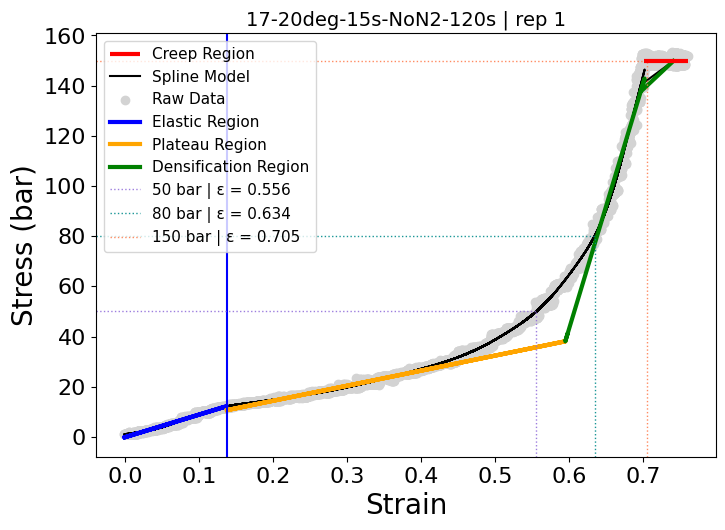

Score: 80/100 → PASS
  elastic_r2                     15/15  R²=0.972
  yield_accuracy                 10/10  |linear-GAM|=0.03 bar (0.3%)
  elastic_modulus                 5/5  E=90.0 bar
  junction_continuity             0/15  gap=13.0%
  plateau_flatness                1/5  slope/E=0.668
  plateau_r2_start                9/10  R²(first 40%)=0.883
  slope_ordering                  8/8  densif=978.2 > plateau=60.1
  densification_r2                2/2  R²=0.878
  elastic_vs_plateau             10/10  E=90.0 > slope=60.1
  breakpoint_order                5/5  bp1=0.137 < cp=0.595 < max=0.740
  densif_vs_elastic               5/5  densif/E=10.87
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=62.6 vs creep=149.8


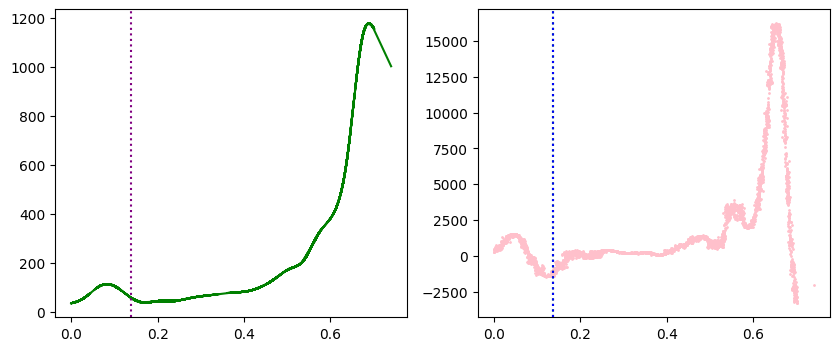

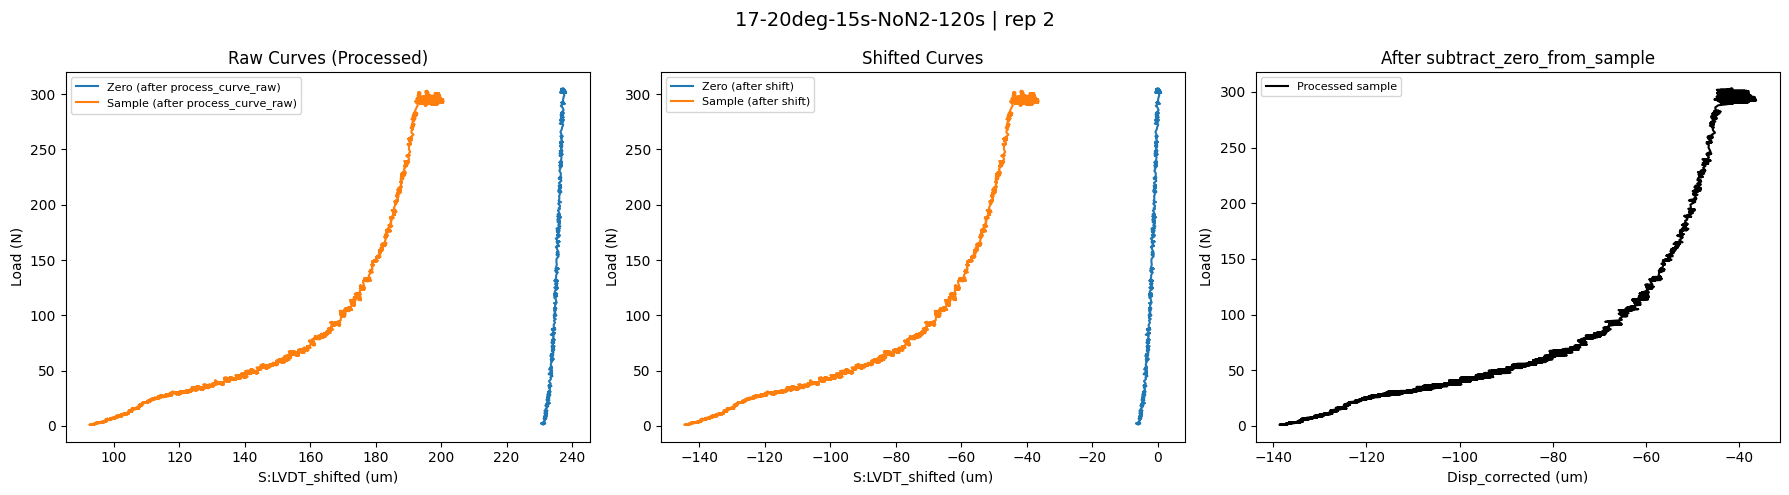

Average Standard Deviation: 60.19565024669422
Cutoff = 0.2490434868962811
PW + Double: 0.12289590272970444
Piecewise Chosen! 0.13104740356499073 | Drop Calculation: 0.11719394289326246
Cutoff = 0.2490434868962811
{'name': '17-20deg-15s-NoN2-120s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(137.66800000000003), 'Elastic Modulus': np.float64(99.97874964729873), 'Yield Strength': np.float64(13.418587197456905), 'Changepoint': np.float64(0.5583263746633792), 'Slope Plateau': np.float64(64.50645639927116), 'Slope Densification': np.float64(920.0113052904236), 'Creep Strain': np.float64(0.05911885461779387), 'Strain at 50 bar': 0.5190750264538431, 'Strain at 80 bar': 0.5986648215884891, 'Strain at 150 bar': 0.6720800577570994, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(60.19565024669422)}


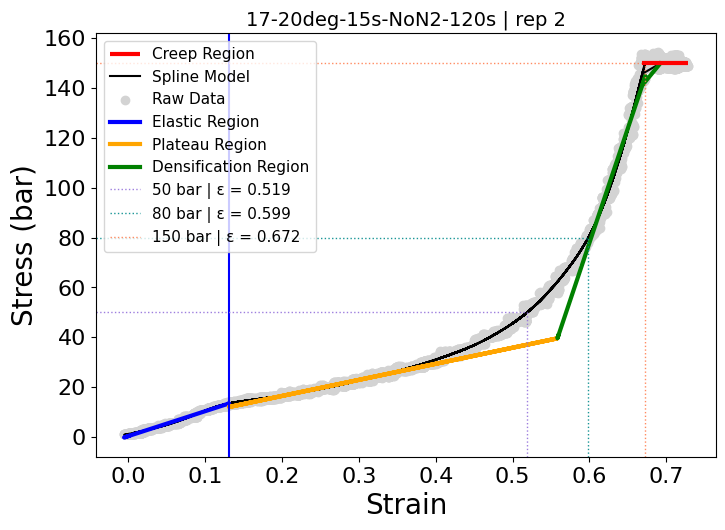

Score: 80/100 → PASS
  elastic_r2                     15/15  R²=0.980
  yield_accuracy                 10/10  |linear-GAM|=0.02 bar (0.2%)
  elastic_modulus                 5/5  E=100.0 bar
  junction_continuity             0/15  gap=10.7%
  plateau_flatness                1/5  slope/E=0.645
  plateau_r2_start                9/10  R²(first 40%)=0.913
  slope_ordering                  8/8  densif=920.0 > plateau=64.5
  densification_r2                2/2  R²=0.894
  elastic_vs_plateau             10/10  E=100.0 > slope=64.5
  breakpoint_order                5/5  bp1=0.131 < cp=0.558 < max=0.692
  densif_vs_elastic               5/5  densif/E=9.20
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=62.2 vs creep=149.9


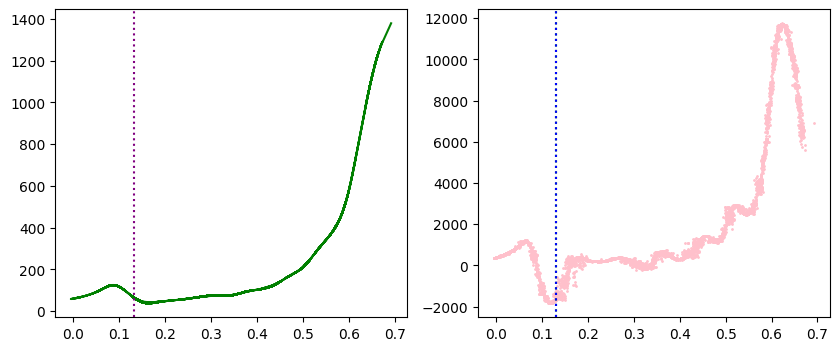

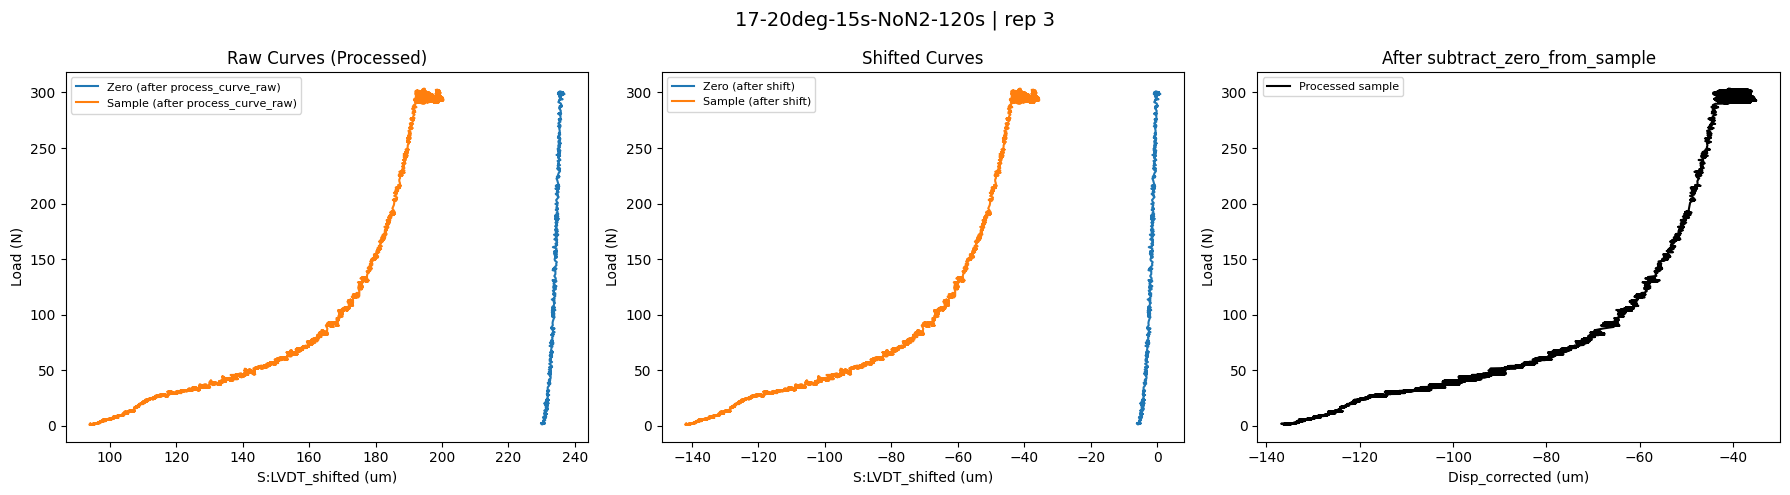

Average Standard Deviation: 60.144657694866936
Cutoff = 0.24956301210217166
PW + Double: 0.12598207768360398
Piecewise Chosen! 0.13270991913127572 | Drop Calculation: 0.1409744608551679
Cutoff = 0.24956301210217166
{'name': '17-20deg-15s-NoN2-120s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(135.58520000000001), 'Elastic Modulus': np.float64(102.6332699347995), 'Yield Strength': np.float64(13.520393246752644), 'Changepoint': np.float64(0.5574899933249606), 'Slope Plateau': np.float64(56.62033697086951), 'Slope Densification': np.float64(893.856146207129), 'Creep Strain': np.float64(0.06252209625125615), 'Strain at 50 bar': 0.5223743303706156, 'Strain at 80 bar': 0.6016576870726464, 'Strain at 150 bar': 0.6775743744813669, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(60.144657694866936)}


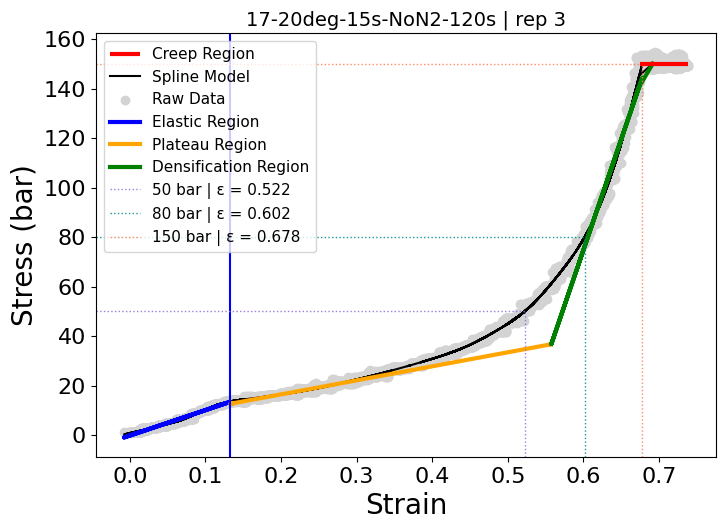

Score: 85/100 → PASS
  elastic_r2                     15/15  R²=0.970
  yield_accuracy                  9/10  |linear-GAM|=0.13 bar (1.0%)
  elastic_modulus                 5/5  E=102.6 bar
  junction_continuity             6/15  gap=6.1%
  plateau_flatness                1/5  slope/E=0.552
  plateau_r2_start                9/10  R²(first 40%)=0.944
  slope_ordering                  8/8  densif=893.9 > plateau=56.6
  densification_r2                2/2  R²=0.881
  elastic_vs_plateau             10/10  E=102.6 > slope=56.6
  breakpoint_order                5/5  bp1=0.133 < cp=0.557 < max=0.692
  densif_vs_elastic               5/5  densif/E=8.71
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=61.2 vs creep=150.0
Condition: 17-5deg-60s-N2-1800s | pairs: 3


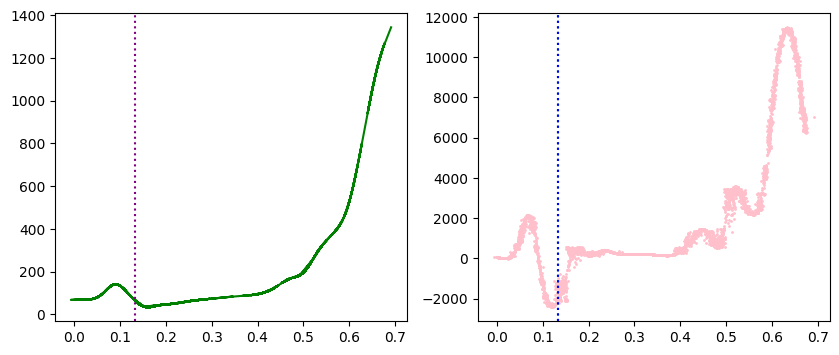

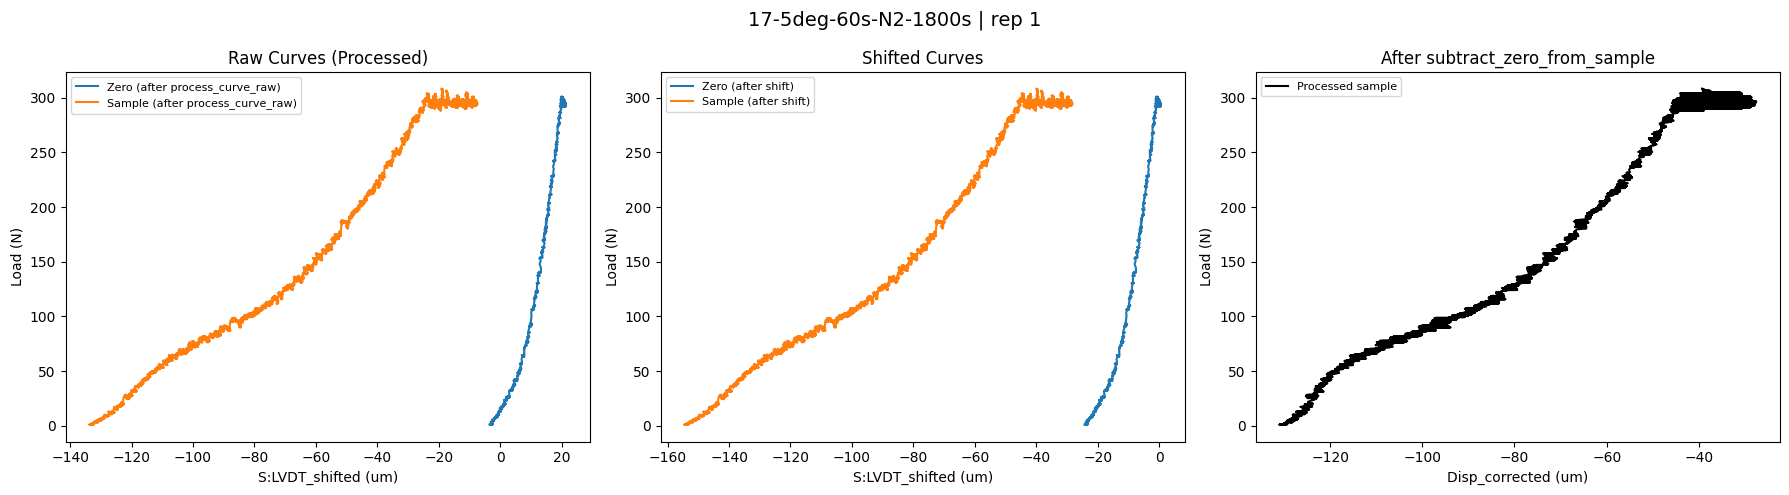

Average Standard Deviation: 52.176994148110985
Cutoff = 0.2
PW + Double: 0.08172947739534499
Piecewise Chosen! 0.08350867223103699 | Drop Calculation: 0.09371744514944336
Cutoff = 0.2
{'name': '17-5deg-60s-N2-1800s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(130.30200000000002), 'Elastic Modulus': np.float64(335.27983264414274), 'Yield Strength': np.float64(26.8582462062964), 'Changepoint': np.float64(0.43636466197625434), 'Slope Plateau': np.float64(116.5861820043074), 'Slope Densification': np.float64(368.06215620924496), 'Creep Strain': np.float64(0.12715895023470736), 'Strain at 50 bar': 0.27485675936151177, 'Strain at 80 bar': 0.4438859821680661, 'Strain at 150 bar': 0.65955707729716, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(52.176994148110985)}


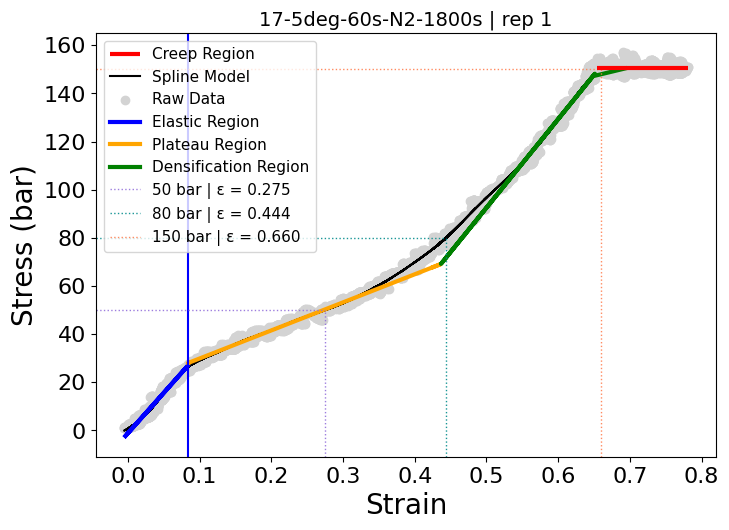

Score: 86/100 → PASS
  elastic_r2                     14/15  R²=0.963
  yield_accuracy                  8/10  |linear-GAM|=0.44 bar (1.7%)
  elastic_modulus                 5/5  E=335.3 bar
  junction_continuity             9/15  gap=4.2%
  plateau_flatness                1/5  slope/E=0.348
  plateau_r2_start                9/10  R²(first 40%)=0.945
  slope_ordering                  8/8  densif=368.1 > plateau=116.6
  densification_r2                2/2  R²=0.957
  elastic_vs_plateau             10/10  E=335.3 > slope=116.6
  breakpoint_order                5/5  bp1=0.084 < cp=0.436 < max=0.694
  densif_vs_elastic               5/5  densif/E=1.10
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=78.0 vs creep=150.4


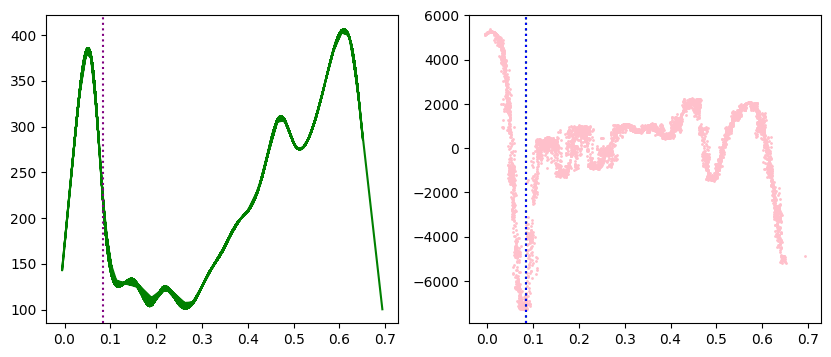

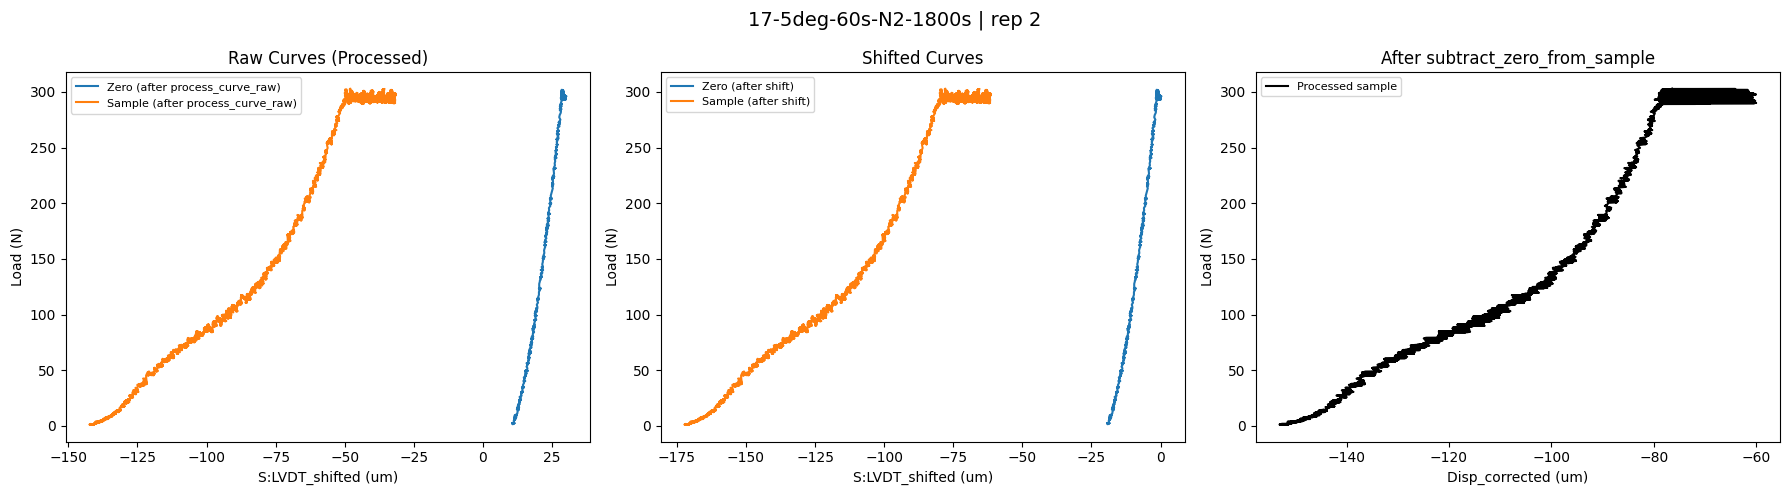

Average Standard Deviation: 53.883232937927964
Cutoff = 0.011173216986144985
PW + Double: 0.044887712473377264
Piecewise Chosen! 0.010603066443975883 | Drop Calculation: 0.1388062959914612
Cutoff = 0.011173216986144985
{'name': '17-5deg-60s-N2-1800s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(152.3492), 'Elastic Modulus': np.float64(66.42077797163748), 'Yield Strength': np.float64(1.9024424058980354), 'Changepoint': np.float64(0.4237510435428146), 'Slope Plateau': np.float64(267.0020262840045), 'Slope Densification': np.float64(714.436208597691), 'Creep Strain': np.float64(0.12587529176392143), 'Strain at 50 bar': 0.258074552247719, 'Strain at 80 bar': 0.3710479881801515, 'Strain at 150 bar': 0.4806996680115154, 'Strain at 500 bar': nan, 'Good Fit': False, 'Average Standard Deviation': np.float64(53.883232937927964)}


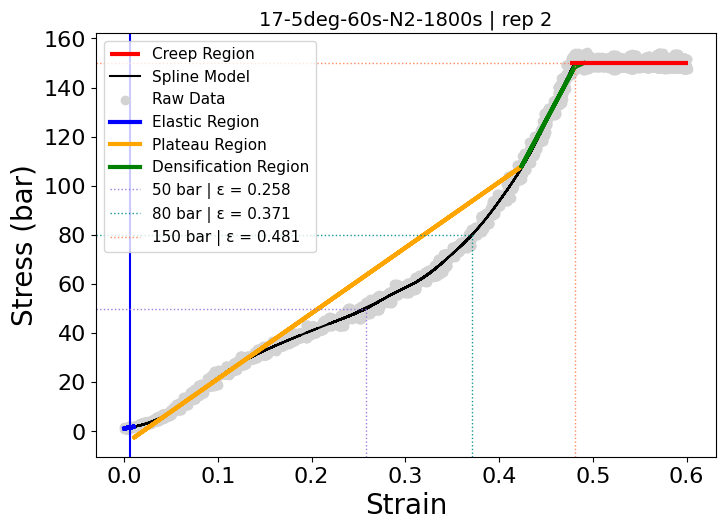

Score: 30/100 → FAIL
  elastic_r2                      6/15  R²=0.430
  yield_accuracy                 10/10  |linear-GAM|=0.01 bar (0.3%)
  elastic_modulus                 5/5  E=66.4 bar
  junction_continuity             0/15  gap=230.4%
  plateau_flatness                0/5  CATASTROPHIC: slope=267.0 > E=66.4
  plateau_r2_start               10/10  R²(first 40%)=0.973
  slope_ordering                  8/8  densif=714.4 > plateau=267.0
  densification_r2                2/2  R²=0.964
  elastic_vs_plateau              0/10  E=66.4 > slope=267.0
  breakpoint_order                5/5  bp1=0.011 < cp=0.424 < max=0.490
  densif_vs_elastic               5/5  densif/E=10.76
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=107.1 vs creep=150.0
  _catastrophic_penalty           0/0  slope > modulus — score halved


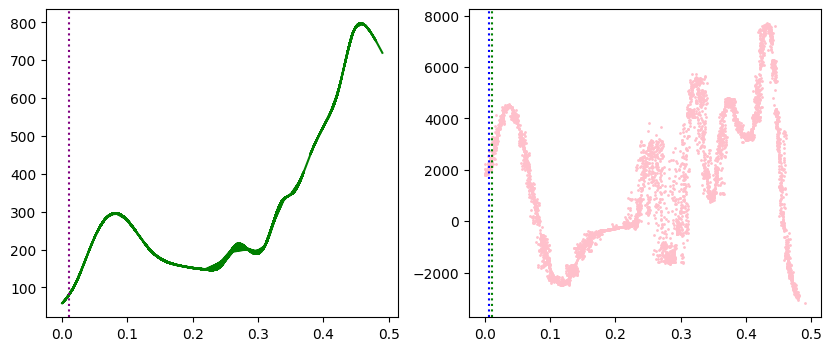

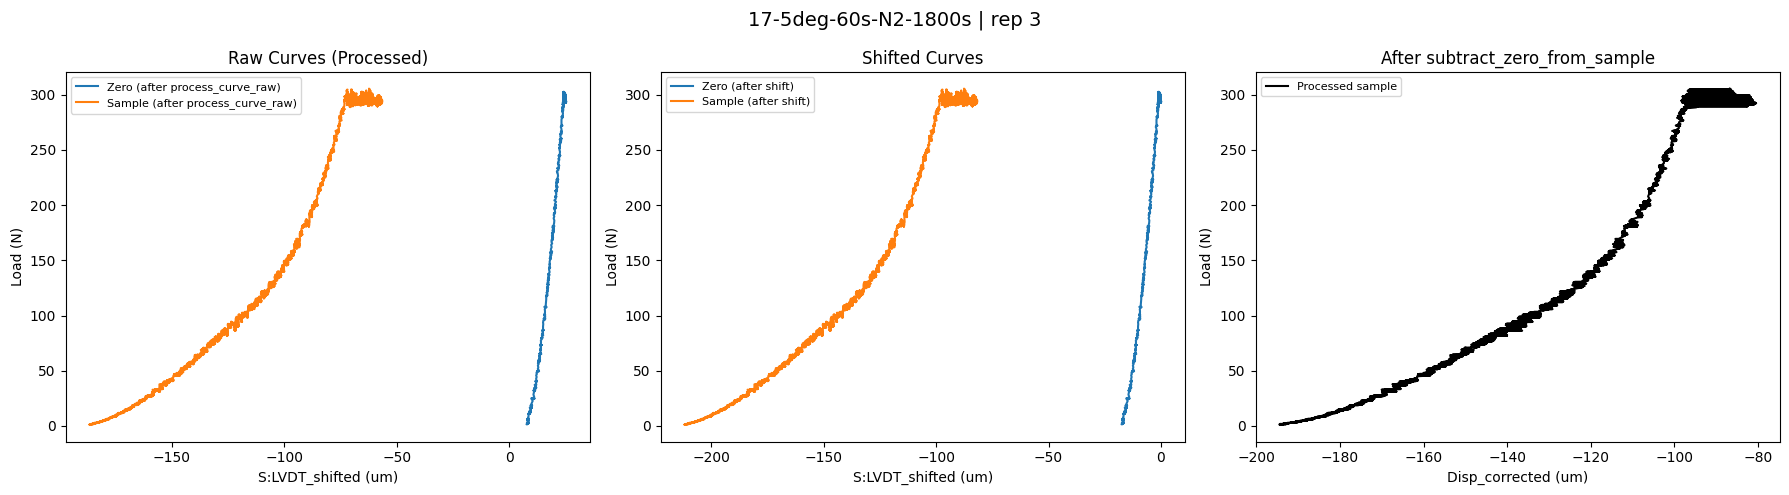

Average Standard Deviation: 56.92605558912301
Cutoff = 0.04872892711714771
PW + Double: 0.0479052938571341
Drop Chosen! 0.250680787283875 | Piecewise Calculation: 0.014276041664112301
Cutoff = 0.04872892711714771
{'name': '17-5deg-60s-N2-1800s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(194.1576), 'Elastic Modulus': np.float64(163.0734521397568), 'Yield Strength': np.float64(37.96357510537686), 'Changepoint': np.float64(0.41907389202928313), 'Slope Plateau': np.float64(235.82589490029872), 'Slope Densification': np.float64(959.5879412923197), 'Creep Strain': np.float64(0.08686551543694399), 'Strain at 50 bar': 0.29869229958110155, 'Strain at 80 bar': 0.39886316572684366, 'Strain at 150 bar': 0.4930086013913467, 'Strain at 500 bar': nan, 'Good Fit': False, 'Average Standard Deviation': np.float64(56.92605558912301)}


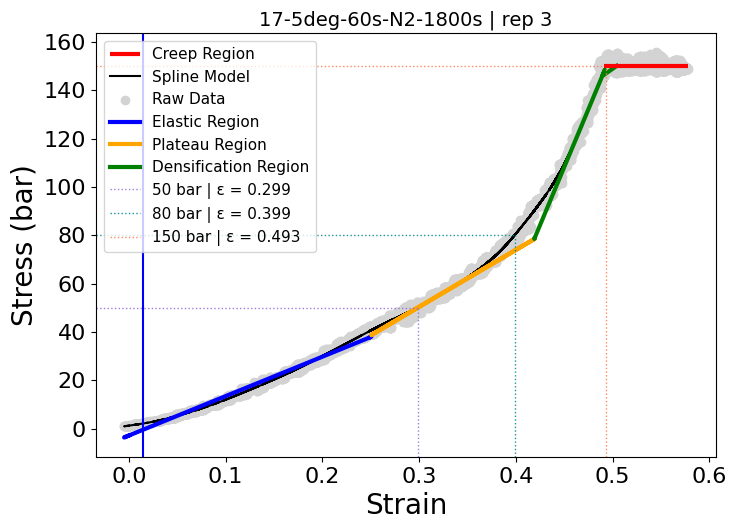

Score: 37/100 → FAIL
  elastic_r2                     15/15  R²=0.981
  yield_accuracy                  3/10  |linear-GAM|=2.76 bar (6.8%)
  elastic_modulus                 5/5  E=163.1 bar
  junction_continuity            12/15  gap=1.9%
  plateau_flatness                0/5  CATASTROPHIC: slope=235.8 > E=163.1
  plateau_r2_start                9/10  R²(first 40%)=0.854
  slope_ordering                  8/8  densif=959.6 > plateau=235.8
  densification_r2                2/2  R²=0.928
  elastic_vs_plateau              0/10  E=163.1 > slope=235.8
  breakpoint_order                5/5  bp1=0.251 < cp=0.419 < max=0.504
  densif_vs_elastic               5/5  densif/E=5.88
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=90.1 vs creep=150.1
  _catastrophic_penalty           0/0  slope > modulus — score halved
Condition: 17-5deg-60s-NoN2-1800s | pairs: 3


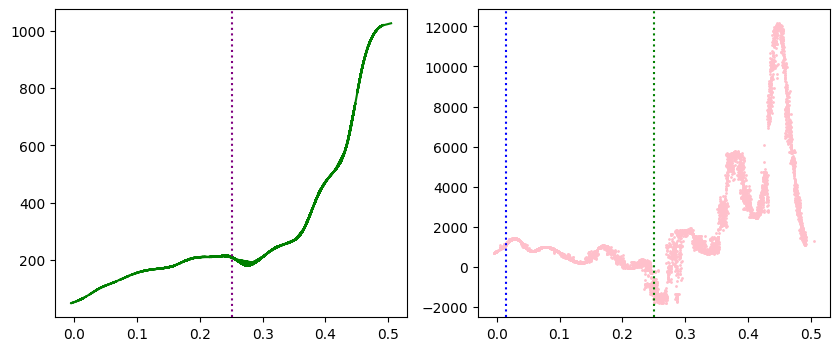

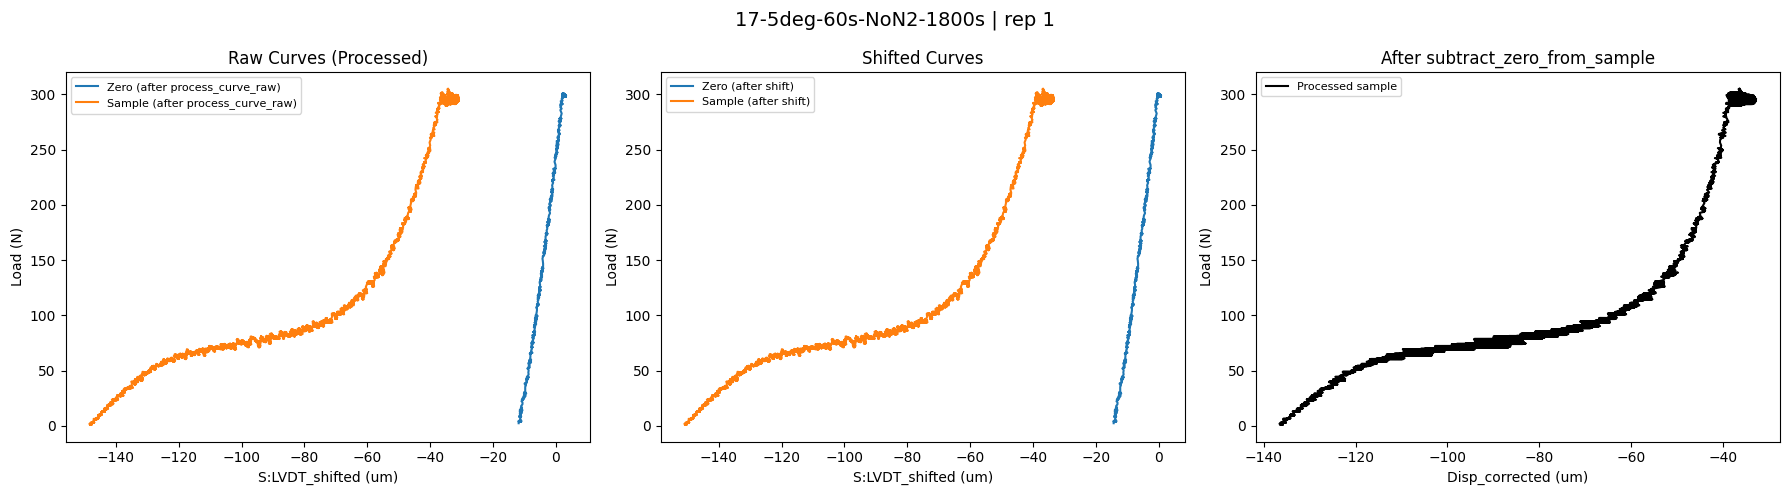

Average Standard Deviation: 55.110852775714825
Cutoff = 0.3156055609224361
PW + Double: 0.1236081191146277
Piecewise Chosen! 0.12926356988268387 | Drop Calculation: 0.11986417187089493
Cutoff = 0.3156055609224361
{'name': '17-5deg-60s-NoN2-1800s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(136.2202), 'Elastic Modulus': np.float64(208.32212582609546), 'Yield Strength': np.float64(28.867246441358297), 'Changepoint': np.float64(0.6169459796727564), 'Slope Plateau': np.float64(43.003976597979374), 'Slope Densification': np.float64(938.1370998855693), 'Creep Strain': np.float64(0.045123997762446355), 'Strain at 50 bar': 0.5251705665461216, 'Strain at 80 bar': 0.6408922548935997, 'Strain at 150 bar': 0.7165743340698651, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.110852775714825)}


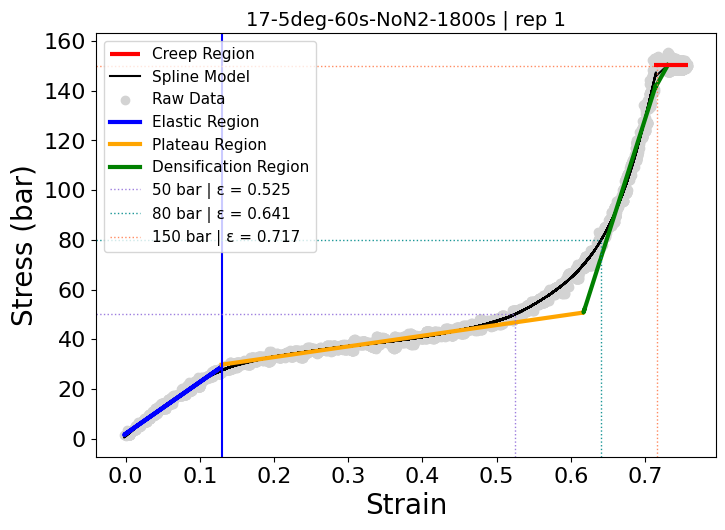

Score: 86/100 → PASS
  elastic_r2                     15/15  R²=0.987
  yield_accuracy                  5/10  |linear-GAM|=1.42 bar (5.2%)
  elastic_modulus                 5/5  E=208.3 bar
  junction_continuity            10/15  gap=3.1%
  plateau_flatness                2/5  slope/E=0.206
  plateau_r2_start                9/10  R²(first 40%)=0.866
  slope_ordering                  8/8  densif=938.1 > plateau=43.0
  densification_r2                2/2  R²=0.910
  elastic_vs_plateau             10/10  E=208.3 > slope=43.0
  breakpoint_order                5/5  bp1=0.129 < cp=0.617 < max=0.731
  densif_vs_elastic               5/5  densif/E=4.50
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=69.9 vs creep=150.4


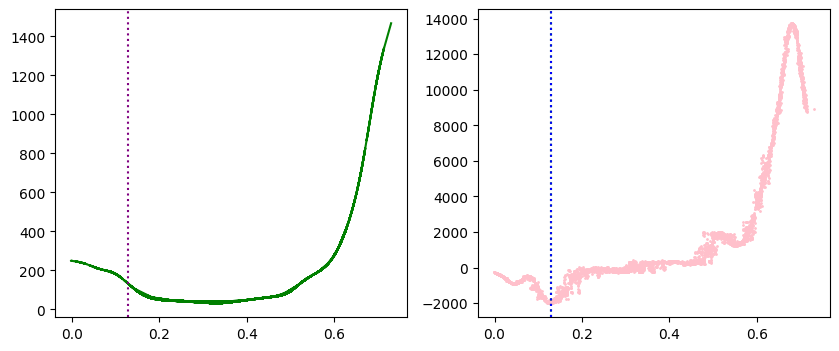

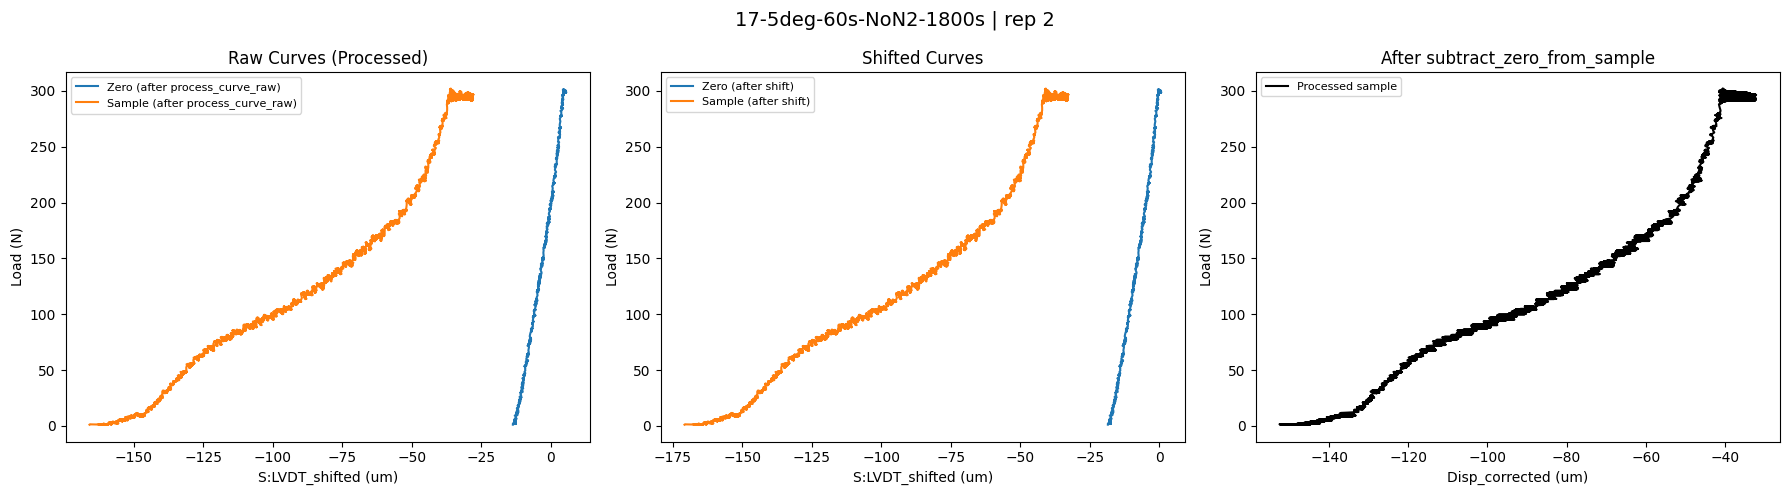

Average Standard Deviation: 54.06308101041306
Cutoff = 0.19625801216827382
PW + Double: 0.07962809510798982
Piecewise Chosen! 0.07873957657921522 | Drop Calculation: 0.19731947130896496
Cutoff = 0.19625801216827382
{'name': '17-5deg-60s-NoN2-1800s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(146.9644), 'Elastic Modulus': np.float64(54.932450009372594), 'Yield Strength': np.float64(5.426149485462396), 'Changepoint': np.float64(0.7370536574931889), 'Slope Plateau': np.float64(230.69838910636008), 'Slope Densification': np.float64(618.2361763271758), 'Creep Strain': np.float64(0.05937409062073806), 'Strain at 50 bar': 0.3449371386255252, 'Strain at 80 bar': 0.5450750835359977, 'Strain at 150 bar': nan, 'Strain at 500 bar': nan, 'Good Fit': False, 'Average Standard Deviation': np.float64(54.06308101041306)}


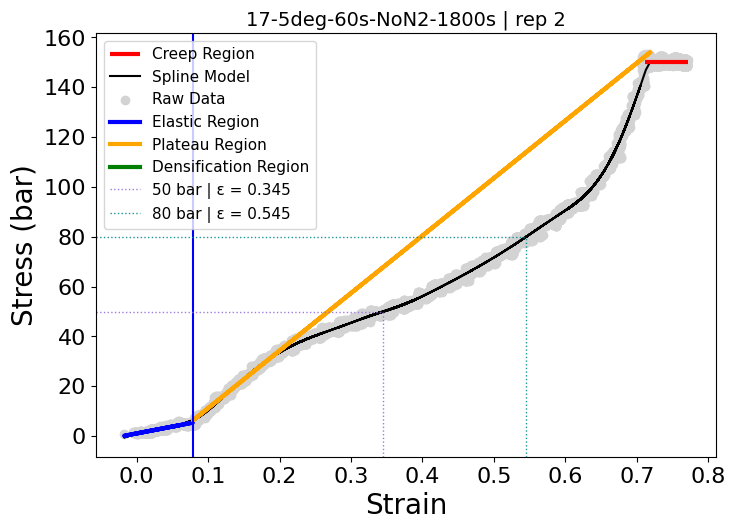

Score: 22/100 → FAIL
  elastic_r2                     13/15  R²=0.869
  yield_accuracy                  0/10  |linear-GAM|=0.74 bar (12.0%)
  elastic_modulus                 5/5  E=54.9 bar
  junction_continuity             0/15  gap=17.3%
  plateau_flatness                0/5  CATASTROPHIC: slope=230.7 > E=54.9
  plateau_r2_start                8/10  R²(first 40%)=0.757
  slope_ordering                  8/8  densif=618.2 > plateau=230.7
  densification_r2                0/2  insufficient data
  elastic_vs_plateau              0/10  E=54.9 > slope=230.7
  breakpoint_order                2/5  bp1=0.079 < cp=0.737 < max=0.719
  densif_vs_elastic               5/5  densif/E=11.25
  data_density                    3/5  2/3 regions have ≥5 pts
  changepoint_vs_creep            0/5  GAM(cp)=167.6 vs creep=150.1
  _catastrophic_penalty           0/0  slope > modulus — score halved


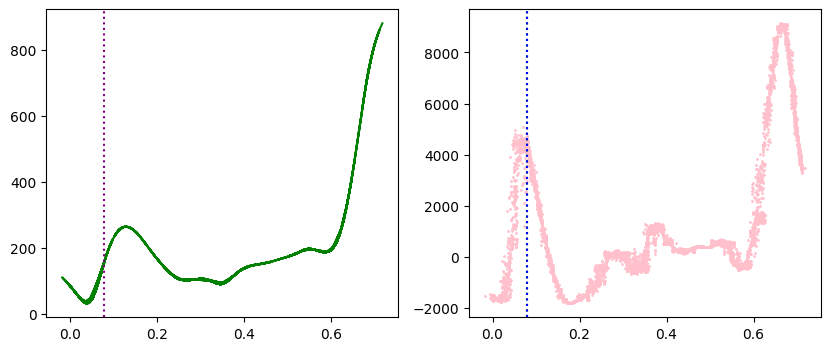

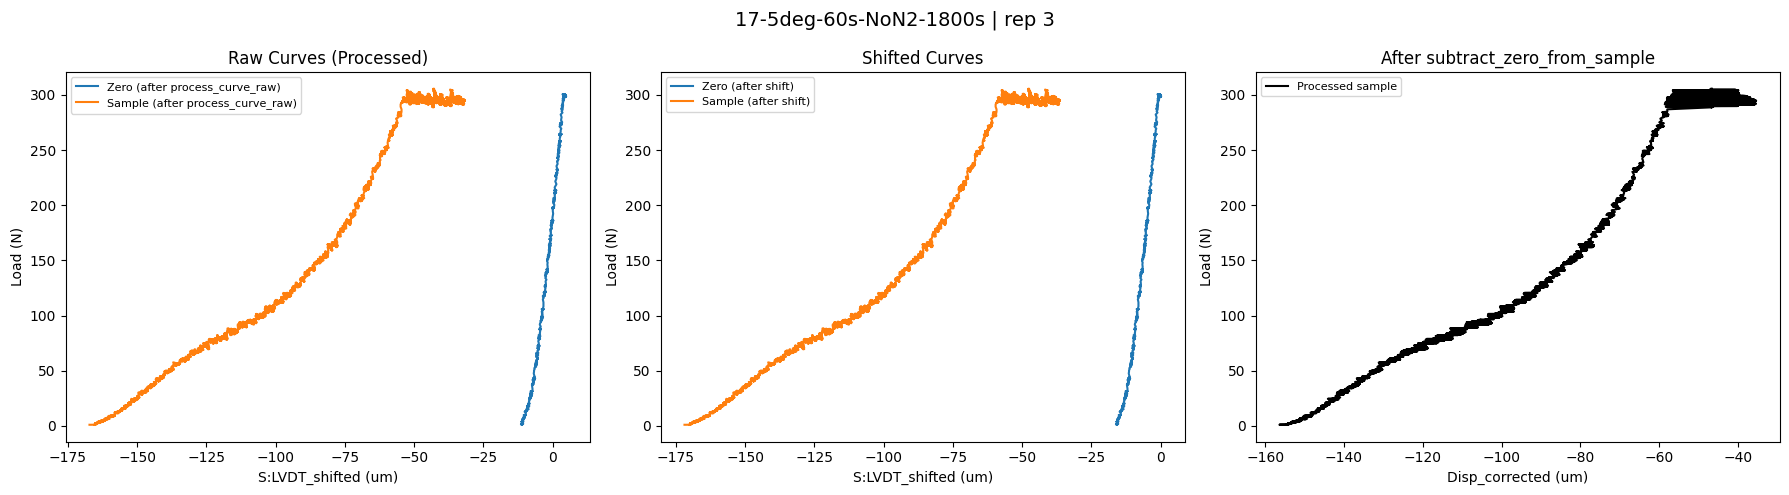

Average Standard Deviation: 54.80748785070425
Cutoff = 0.2
PW + Double: 0.033225639142038785
Drop Chosen! 0.2022904813198382 | Piecewise Calculation: 0.02362363118850171
Cutoff = 0.2
{'name': '17-5deg-60s-NoN2-1800s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(156.2608), 'Elastic Modulus': np.float64(182.95994215068603), 'Yield Strength': np.float64(36.54503732737971), 'Changepoint': np.float64(0.45739028039623514), 'Slope Plateau': np.float64(115.56565051289917), 'Slope Densification': np.float64(509.9375640404262), 'Creep Strain': np.float64(0.13671052014362117), 'Strain at 50 bar': 0.32784013723919736, 'Strain at 80 bar': 0.4698782298784896, 'Strain at 150 bar': nan, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.80748785070425)}


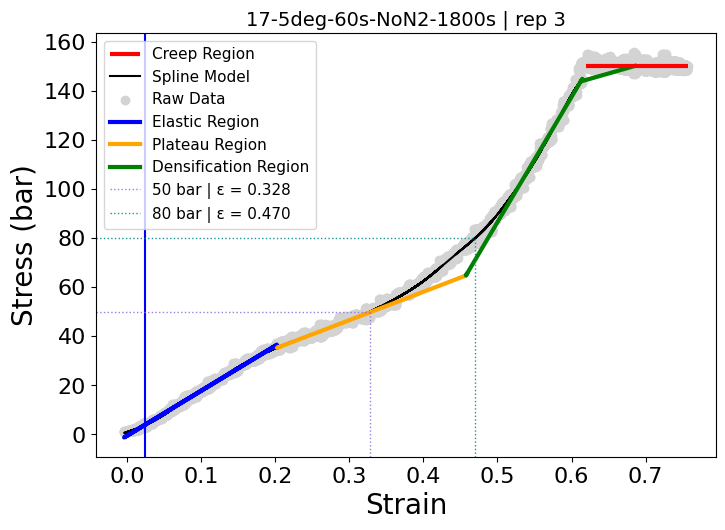

Score: 87/100 → PASS
  elastic_r2                     15/15  R²=0.994
  yield_accuracy                  7/10  |linear-GAM|=1.13 bar (3.2%)
  elastic_modulus                 5/5  E=183.0 bar
  junction_continuity            10/15  gap=3.4%
  plateau_flatness                1/5  slope/E=0.632
  plateau_r2_start                9/10  R²(first 40%)=0.914
  slope_ordering                  8/8  densif=509.9 > plateau=115.6
  densification_r2                2/2  R²=0.957
  elastic_vs_plateau             10/10  E=183.0 > slope=115.6
  breakpoint_order                5/5  bp1=0.202 < cp=0.457 < max=0.685
  densif_vs_elastic               5/5  densif/E=2.79
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=76.8 vs creep=150.2


7

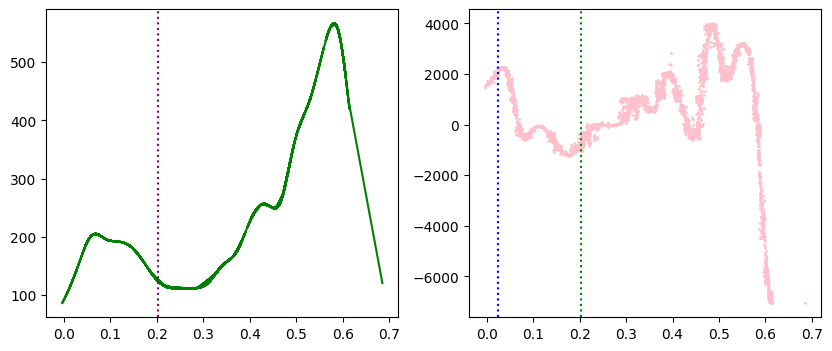

In [15]:
# Example run: processes each pair, shows both requested plots per pair, and returns all outputs.

pipeline_result = process_zero_sample_pairs_pipeline(
    folder_name="old data",
    data_root="compression-test-data",
    strict=True,
    load_cutoff=1.0,
    thickness_info=False,
    creep_info=True,
)

len(pipeline_result)